# Ensemble Methods (Ансамбли)

In [1]:
import os
import time
from collections import Counter
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit,
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder, TargetEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, StackingRegressor,
    RandomForestClassifier, AdaBoostClassifier, StackingClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    mean_absolute_error, root_mean_squared_error, r2_score,
    make_scorer, mean_absolute_percentage_error, roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Source

import shap
import optuna

import lightgbm as lgb
import catboost as cb
import xgboost as xgb

c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_STATE = 21

dataset_dir_path = "../../../datasets"

In [3]:
def eval_model(y_true, y_pred, mode='regression'):
    if mode == "regression":
        rmse = root_mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        metrics = {
            "rmse": [rmse],
            "mae": [mae],
            "r2": [r2]
        }
    elif mode == "classification":
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')

        metrics = {
            "accuracy": [accuracy],
            "f1": [f1],
            "precision": [precision],
            "recall": [recall],
            "roc_auc": [roc_auc],
        }
    else:
        metrics = {}

    return metrics

## Задание 1: Сравнение ансамблей

### Описание:
Вы — исследователь данных в компании, которая занимается прогнозированием спроса на продукты. Вам нужно сравнить эффективность различных ансамблевых методов:


Bagging (например, Random Forest)

Boosting (например, AdaBoost)
Stacking
Требования:

Выберите датасет (например, Kaggle: Store Item Demand Forecasting).
Постройте модели с использованием каждого из методов.
Сравните их по метрикам (RMSE, MAE, R² для регрессии или accuracy, F1-score для классификации).
Проанализируйте, какой метод показал лучшие результаты и почему.
Дополнительно:

Попробуйте настроить гиперпараметры для каждой модели.


In [4]:
data_dir_path = "../../../datasets/grocery_store_sales"
dataset_file_path = os.path.join(data_dir_path, "grocery_chain_data.json")

# https://www.kaggle.com/c/demand-forecasting-kernels-only

df = pd.read_json(dataset_file_path, convert_dates=['transaction_date'])

df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22


In [5]:
df["store_name"].value_counts(normalize=True)

store_name
City Fresh Store      0.120205
SuperSave Central     0.118670
ValuePlus Market      0.113043
GreenGrocer Plaza     0.112532
Corner Grocery        0.111509
FamilyFood Express    0.109974
MegaMart Westside     0.109463
QuickStop Market      0.106394
FreshMart Downtown    0.098210
Name: proportion, dtype: float64

In [6]:
df["aisle"].value_counts(normalize=True)

aisle
Beverages            0.098485
Personal Care        0.096970
Snacks & Candy       0.095960
Canned Goods         0.095960
Frozen Foods         0.094949
Health & Wellness    0.092424
Bakery               0.091919
Household Items      0.088384
Dairy                0.082828
Meat & Seafood       0.081313
Produce              0.080808
Name: proportion, dtype: float64

In [7]:
df["product_name"].value_counts(normalize=True)

product_name
Chicken Breast    0.066162
Onions            0.064141
Tomatoes          0.063636
Bread             0.061111
Potatoes          0.059596
Eggs              0.057576
Salmon            0.057071
Cereal            0.057071
Orange Juice      0.056566
Yogurt            0.055051
Milk              0.054545
Cheese            0.053030
Apples            0.052020
Bananas           0.051515
Pasta             0.050000
Rice              0.049495
Carrots           0.046465
Ground Beef       0.044949
Name: proportion, dtype: float64

In [8]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [9]:
df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points,year,month,day_of_week,is_weekend
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2,7.46,14.92,0.00,14.92,377,2023,8,5,1
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111,2024,2,1,0
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4,7.38,29.52,4.04,25.48,301,2023,11,3,0
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490,2025,1,0,0
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22,2023,10,4,0


In [10]:
X = df.drop(columns=["quantity", "transaction_date"]).copy()
y = df.loc[:, "quantity"].copy().astype(float)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=RANDOM_STATE)

In [12]:
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_enc = ohe.fit_transform(X_train)
X_test_enc = ohe.transform(X_test)

In [13]:
# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)
# y_test_enc = le.transform(y_test)

In [14]:
xgbr = xgb.XGBRegressor(n_estimators=3, random_state=RANDOM_STATE)
rfc = RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE)
adabc = AdaBoostRegressor(estimator=RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE))
sc = StackingRegressor(estimators=[
    ('rfc', RandomForestRegressor(n_estimators=3, random_state=RANDOM_STATE)),
    ('lr', xgb.XGBRegressor(n_estimators=3, random_state=RANDOM_STATE)),
])

models = {
    'XGBoost': xgbr,
    'RandomForest (Bagging)': rfc,
    'AdaBoost (Boosting)': adabc,
    'Stacking': sc
}

In [15]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_test_enc)
    
    metrics = eval_model(y_test, y_pred, mode='regression')
    mdf = pd.DataFrame({
        "model": [name],
        **metrics
    })
    res_metrics_df = pd.concat([res_metrics_df, mdf])

In [16]:
res_metrics_df

,model,rmse,mae,r2
0,XGBoost,1.419747,1.215650,-0.013851
0,RandomForest (Bagging),1.672884,1.395623,-0.407614
0,AdaBoost (Boosting),1.497910,1.273288,-0.128557
0,Stacking,1.412592,1.210376,-0.003657


# Gradient Boosting (Градиентный бустинг)

## Задание 1: Прогнозирование оттока клиентов

### Описание:
Телекоммуникационная компания хочет предсказать, какие клиенты могут уйти к конкурентам. Вам нужно построить модель на основе градиентного бустинга.
Требования:

Используйте датасет Telco Customer Churn.
Постройте модель с использованием GradientBoostingClassifier из sklearn.
Оцените модель с помощью метрик: accuracy, precision, recall, ROC-AUC.
Проанализируйте важность признаков.
Дополнительно:

Попробуйте использовать XGBoost или LightGBM и сравните результаты.


In [17]:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [18]:
dataset_file_path = os.path.join(dataset_dir_path, "telco_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(dataset_file_path, index_col="customerID", na_values=[' '])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
X = df.drop(columns='Churn').copy()
y = df.loc[:, "Churn"].copy()

In [22]:
num_features = X.select_dtypes("number").columns.tolist()
cat_features = X.select_dtypes("object").columns.tolist()

print(num_features)
print(cat_features)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
], remainder='passthrough')

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [25]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [26]:
gbc = GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE)
gbc.fit(X_train_enc, y_train_enc)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [27]:
y_pred = gbc.predict(X_test_enc)
metrics = eval_model(y_test_enc, y_pred, mode="classification")

res_metrics_df = pd.DataFrame({
    "model": str(gbc),
    **metrics
})

res_metrics_df

,model,accuracy,f1,precision,recall,roc_auc
0,"GradientBoostingClassifier(n_estimators=50, ra...",0.792239,0.708606,0.645238,0.483066,0.69353


In [28]:
cbc = cb.CatBoostClassifier(n_estimators=50, random_seed=RANDOM_STATE)
lgbc = lgb.LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE)
xgbc = xgb.XGBClassifier(n_estimators=50, random_state=RANDOM_STATE)

models = {
    "CatBoost": cbc,
    "LGB": lgbc,
    "XGB": xgbc
}

In [29]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():

    model.fit(X_train_enc, y_train_enc)
    y_pred = model.predict(X_test_enc)

    metrics = eval_model(y_test_enc, y_pred, mode="classification")

    metrics_df = pd.DataFrame({
        "model": name,
        **metrics
    })
    res_metrics_df = pd.concat([res_metrics_df, metrics_df])

res_metrics_df

Learning rate set to 0.317559
0:	learn: 0.5218925	total: 197ms	remaining: 9.65s
1:	learn: 0.4646500	total: 203ms	remaining: 4.87s
2:	learn: 0.4313283	total: 208ms	remaining: 3.26s
3:	learn: 0.4120335	total: 215ms	remaining: 2.48s
4:	learn: 0.4029533	total: 220ms	remaining: 1.98s
5:	learn: 0.3960123	total: 223ms	remaining: 1.63s
6:	learn: 0.3913897	total: 226ms	remaining: 1.39s
7:	learn: 0.3863835	total: 229ms	remaining: 1.2s
8:	learn: 0.3823582	total: 232ms	remaining: 1.06s
9:	learn: 0.3797362	total: 235ms	remaining: 942ms
10:	learn: 0.3771345	total: 238ms	remaining: 845ms
11:	learn: 0.3741488	total: 241ms	remaining: 764ms
12:	learn: 0.3716169	total: 244ms	remaining: 695ms
13:	learn: 0.3683330	total: 249ms	remaining: 640ms
14:	learn: 0.3663409	total: 252ms	remaining: 588ms
15:	learn: 0.3638176	total: 255ms	remaining: 542ms
16:	learn: 0.3617646	total: 258ms	remaining: 500ms
17:	learn: 0.3598225	total: 261ms	remaining: 463ms
18:	learn: 0.3583110	total: 264ms	remaining: 431ms
19:	learn: 0

c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,f1,precision,recall,roc_auc
0,CatBoost,0.787506,0.710071,0.621739,0.509804,0.698845
0,LGB,0.799811,0.723511,0.656109,0.516934,0.709498
0,XGB,0.784193,0.704959,0.614880,0.500891,0.693745


In [30]:
importances = gbc.feature_importances_
importance_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': importances
}).sort_values("importance", ascending=False).head(10)

importance_df

,feature,importance
36,cat__Contract_Month-to-month,0.392386
1,num__tenure,0.175128
27,cat__TechSupport_No,0.075068
16,cat__InternetService_Fiber optic,0.070570
2,num__MonthlyCharges,0.064063
18,cat__OnlineSecurity_No,0.063663
3,num__TotalCharges,0.049229
43,cat__PaymentMethod_Electronic check,0.040644
38,cat__Contract_Two year,0.011509
12,cat__MultipleLines_No,0.009356


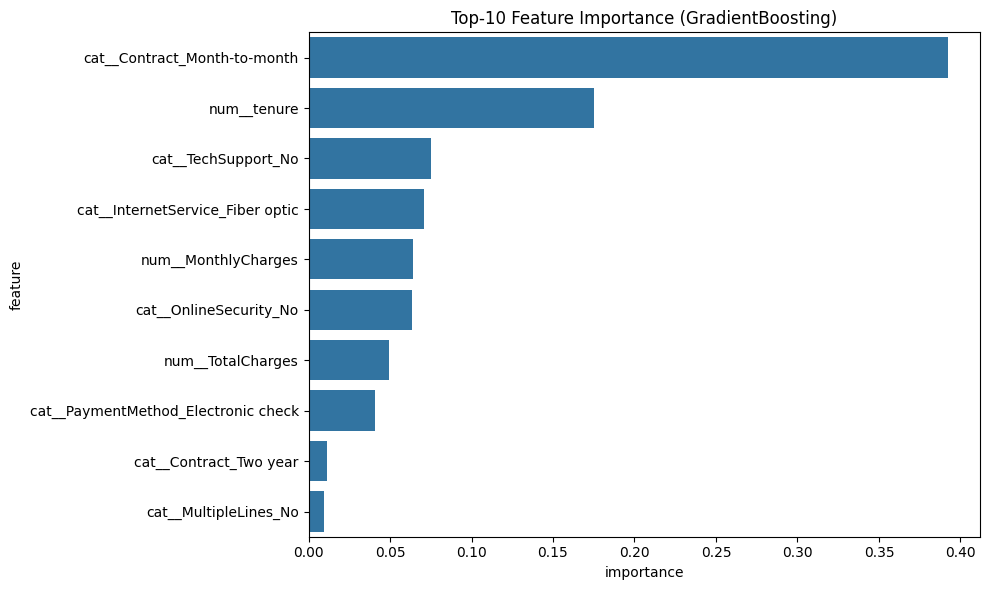

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top-10 Feature Importance (GradientBoosting)')
plt.tight_layout()
plt.show()

# Modern Gradient Boosting Implementations (Современные реализации градиентного бустинга)

## Задание 2: Сравнение XGBoost, LightGBM и CatBoost

### Описание:
Вы — участник соревнования на Kaggle. Вам нужно выбрать лучшую модель для задачи регрессии или классификации.
Требования:

Выберите датасет (например, House Prices: Advanced Regression Techniques).
Постройте модели с использованием:

XGBoost
LightGBM
CatBoost

Сравните их по метрикам (RMSE, MAE, R² для регрессии или accuracy, F1-score для классификации).
Проанализируйте скорость обучения и предсказания каждой модели.
Дополнительно:

Попробуйте настроить гиперпараметры для каждой модели с помощью Optuna или GridSearchCV.


In [32]:
# https://www.kaggle.com/c/house-prices-advanced-regression-techniques

In [33]:
dataset_file_path = os.path.join(dataset_dir_path, "house_prices_advanced_regression_techniques")

df_train = pd.read_csv(os.path.join(dataset_file_path, "train.csv"), index_col='Id')
df_test = pd.read_csv(os.path.join(dataset_file_path, "test.csv"), index_col='Id')

df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [34]:
df_train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [35]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [36]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1455 non-null   object 
 2   LotFrontage    1232 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   Alley          107 non-null    object 
 6   LotShape       1459 non-null   object 
 7   LandContour    1459 non-null   object 
 8   Utilities      1457 non-null   object 
 9   LotConfig      1459 non-null   object 
 10  LandSlope      1459 non-null   object 
 11  Neighborhood   1459 non-null   object 
 12  Condition1     1459 non-null   object 
 13  Condition2     1459 non-null   object 
 14  BldgType       1459 non-null   object 
 15  HouseStyle     1459 non-null   object 
 16  OverallQual    1459 non-null   int64  
 17  OverallCond    1459 non-null   int64  
 18  YearBuilt 

In [37]:
threshold = 0.95

df_train = df_train.loc[:, df_train.isnull().sum() / len(df_train) < threshold]
df_test = df_test.loc[:, df_test.isnull().sum() / len(df_test) < threshold]

In [38]:
X_train_val = df_train.drop(columns="SalePrice").copy()
y_train_val = df_train.loc[:, "SalePrice"].copy()

X_test = df_test.copy()

In [39]:
y_train_val = np.log1p(y_train_val)

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=RANDOM_STATE)

In [41]:
num_features = X_train_val.select_dtypes("number").columns.tolist()
cat_features = X_train_val.select_dtypes("object").columns.tolist()

print(num_features)
print(cat_features)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCon

In [42]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
], remainder="passthrough")

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

In [43]:
# scaler = StandardScaler()

# y_train_scaled = scaler.fit_transform(y_train)
# y_val_scaled = scaler.transform(y_val)

In [44]:
cbr = cb.CatBoostRegressor()
xgbr = xgb.XGBRegressor()
lgbr = lgb.LGBMRegressor()

models = {
    "CatBoost": cbr,
    "XGB": xgbr,
    "LGB": lgbr,
}

In [45]:
res_metrics_df = pd.DataFrame()

for name, model in models.items():
    model.fit(X_train_enc, y_train)
    y_pred = model.predict(X_val_enc)

    y_val_ = np.expm1(y_val)
    y_pred_ = np.expm1(y_pred)

    metrics = eval_model(y_val_, y_pred_)
    metrics_df = pd.DataFrame({
        "model": name,
        **metrics,
    })
    res_metrics_df = pd.concat([res_metrics_df, metrics_df])

res_metrics_df

Learning rate set to 0.041084
0:	learn: 0.3824232	total: 3.36ms	remaining: 3.36s
1:	learn: 0.3727997	total: 7.85ms	remaining: 3.92s
2:	learn: 0.3628910	total: 11.9ms	remaining: 3.96s
3:	learn: 0.3537034	total: 15.5ms	remaining: 3.87s
4:	learn: 0.3445627	total: 19ms	remaining: 3.78s
5:	learn: 0.3365877	total: 24ms	remaining: 3.97s
6:	learn: 0.3288821	total: 28.1ms	remaining: 3.99s
7:	learn: 0.3207295	total: 31.7ms	remaining: 3.93s
8:	learn: 0.3132882	total: 35.6ms	remaining: 3.92s
9:	learn: 0.3060668	total: 40.2ms	remaining: 3.98s
10:	learn: 0.2985865	total: 44ms	remaining: 3.95s
11:	learn: 0.2915234	total: 47.5ms	remaining: 3.91s
12:	learn: 0.2849386	total: 50.9ms	remaining: 3.86s
13:	learn: 0.2785599	total: 55.3ms	remaining: 3.9s
14:	learn: 0.2727485	total: 59ms	remaining: 3.88s
15:	learn: 0.2671474	total: 62.6ms	remaining: 3.85s
16:	learn: 0.2614294	total: 66.1ms	remaining: 3.82s
17:	learn: 0.2561185	total: 70.3ms	remaining: 3.83s
18:	learn: 0.2512044	total: 74.8ms	remaining: 3.86s
1

c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,rmse,mae,r2
0,CatBoost,35721.373492,15222.250298,0.795211
0,XGB,33998.300121,18512.282677,0.814491
0,LGB,34355.630175,16798.744474,0.810571


In [46]:
importances = xgbr.feature_importances_
importance_df = pd.DataFrame({
    'feature': preprocessor.get_feature_names_out(),
    'importance': importances
}).sort_values("importance", ascending=False).head(10)

importance_df

,feature,importance
3,num__OverallQual,0.231079
25,num__GarageCars,0.105013
214,cat__CentralAir_N,0.072772
176,cat__BsmtQual_Ex,0.049890
45,cat__Alley_missing,0.042751
40,cat__MSZoning_RM,0.039553
15,num__GrLivArea,0.032666
117,cat__HouseStyle_SLvl,0.022233
239,cat__GarageType_Attchd,0.017990
223,cat__KitchenQual_Gd,0.015758


C:\Users\Tumbi\AppData\Local\Temp\ipykernel_11212\1382752296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(), y="feature", x="importance", palette='viridis')


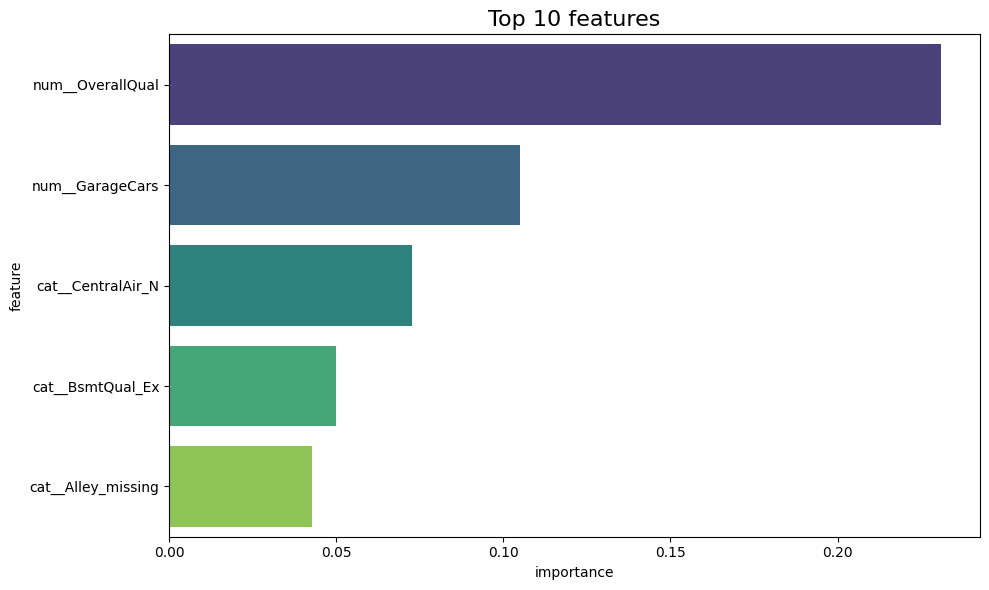

In [47]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(), y="feature", x="importance", palette='viridis')
plt.title("Top 10 features", fontsize=16)
plt.tight_layout()
plt.show()

## Задание 3: Оптимизация гиперпараметров для CatBoost

### Описание:
Вы работаете над задачей предсказания качества вина. Вам нужно оптимизировать гиперпараметры для CatBoost.
Требования:

Используйте датасет Wine Quality.
Постройте модель CatBoost для классификации качества вина.
Оптимизируйте гиперпараметры с помощью Optuna.
Оцените модель с помощью метрик: accuracy, F1-score, ROC-AUC.
Дополнительно:

Визуализируйте важность признаков.


In [48]:
# https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

In [49]:
dataset_file_path = os.path.join(dataset_dir_path, "red_wine_quality/winequality-red.csv")

df = pd.read_csv(dataset_file_path, sep=',')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [50]:
X = df.drop(columns="quality")
y = df.loc[:, "quality"].copy()

In [64]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

In [69]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10)
    }
    model = cb.CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        use_best_model=True
    )
    probs = model.predict_proba(X_val)
    score = roc_auc_score(y_val, probs, multi_class='ovr', average='macro')
    
    return score

In [70]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-01-02 17:56:48,357] A new study created in memory with name: no-name-02a0a69a-3257-449c-8cb3-1695c5a7ba06


0:	learn: 1.7652593	test: 1.7688514	best: 1.7688514 (0)	total: 52.3ms	remaining: 33.4s
1:	learn: 1.7397056	test: 1.7459714	best: 1.7459714 (1)	total: 108ms	remaining: 34.5s
2:	learn: 1.7163531	test: 1.7263869	best: 1.7263869 (2)	total: 150ms	remaining: 31.9s
3:	learn: 1.6936910	test: 1.7072205	best: 1.7072205 (3)	total: 190ms	remaining: 30.2s
4:	learn: 1.6687527	test: 1.6842038	best: 1.6842038 (4)	total: 231ms	remaining: 29.3s
5:	learn: 1.6477260	test: 1.6663355	best: 1.6663355 (5)	total: 274ms	remaining: 29s
6:	learn: 1.6274014	test: 1.6486268	best: 1.6486268 (6)	total: 317ms	remaining: 28.7s
7:	learn: 1.6058057	test: 1.6290179	best: 1.6290179 (7)	total: 357ms	remaining: 28.2s
8:	learn: 1.5850946	test: 1.6114523	best: 1.6114523 (8)	total: 402ms	remaining: 28.2s
9:	learn: 1.5657304	test: 1.5947594	best: 1.5947594 (9)	total: 440ms	remaining: 27.7s
10:	learn: 1.5480202	test: 1.5809418	best: 1.5809418 (10)	total: 480ms	remaining: 27.5s
11:	learn: 1.5295845	test: 1.5651424	best: 1.5651424 

[I 2026-01-02 17:57:12,545] Trial 0 finished with value: 0.8544456278535338 and parameters: {'iterations': 640, 'learning_rate': 0.01954917227646721, 'depth': 9, 'l2_leaf_reg': 1.4594134880834093}. Best is trial 0 with value: 0.8544456278535338.


638:	learn: 0.2585720	test: 0.8299723	best: 0.8297582 (634)	total: 23.8s	remaining: 37.2ms
639:	learn: 0.2579692	test: 0.8299568	best: 0.8297582 (634)	total: 23.8s	remaining: 0us

bestTest = 0.8297582421
bestIteration = 634

Shrink model to first 635 iterations.
0:	learn: 1.7388281	test: 1.7413319	best: 1.7413319 (0)	total: 33.2ms	remaining: 33.8s
1:	learn: 1.6975997	test: 1.7012649	best: 1.7012649 (1)	total: 41.7ms	remaining: 21.2s
2:	learn: 1.6645115	test: 1.6691305	best: 1.6691305 (2)	total: 49.6ms	remaining: 16.8s
3:	learn: 1.6226748	test: 1.6292461	best: 1.6292461 (3)	total: 59.9ms	remaining: 15.2s
4:	learn: 1.5897485	test: 1.5993740	best: 1.5993740 (4)	total: 64.8ms	remaining: 13.1s
5:	learn: 1.5632499	test: 1.5749771	best: 1.5749771 (5)	total: 71.6ms	remaining: 12.1s
6:	learn: 1.5330918	test: 1.5462716	best: 1.5462716 (6)	total: 79.4ms	remaining: 11.5s
7:	learn: 1.5038358	test: 1.5179744	best: 1.5179744 (7)	total: 83.6ms	remaining: 10.6s
8:	learn: 1.4750187	test: 1.4893010	best:

[I 2026-01-02 17:57:17,668] Trial 1 finished with value: 0.8356791657311602 and parameters: {'iterations': 1019, 'learning_rate': 0.045206579194564854, 'depth': 6, 'l2_leaf_reg': 8.437335693477248}. Best is trial 0 with value: 0.8544456278535338.


986:	learn: 0.3747739	test: 0.8628758	best: 0.8619653 (957)	total: 4.72s	remaining: 153ms
987:	learn: 0.3745023	test: 0.8626827	best: 0.8619653 (957)	total: 4.72s	remaining: 148ms
988:	learn: 0.3743697	test: 0.8625147	best: 0.8619653 (957)	total: 4.73s	remaining: 143ms
989:	learn: 0.3739366	test: 0.8626369	best: 0.8619653 (957)	total: 4.73s	remaining: 139ms
990:	learn: 0.3735928	test: 0.8625392	best: 0.8619653 (957)	total: 4.74s	remaining: 134ms
991:	learn: 0.3734538	test: 0.8624212	best: 0.8619653 (957)	total: 4.74s	remaining: 129ms
992:	learn: 0.3733212	test: 0.8625098	best: 0.8619653 (957)	total: 4.75s	remaining: 124ms
993:	learn: 0.3727325	test: 0.8624944	best: 0.8619653 (957)	total: 4.75s	remaining: 120ms
994:	learn: 0.3724928	test: 0.8624021	best: 0.8619653 (957)	total: 4.76s	remaining: 115ms
995:	learn: 0.3721232	test: 0.8622748	best: 0.8619653 (957)	total: 4.76s	remaining: 110ms
996:	learn: 0.3718234	test: 0.8622089	best: 0.8619653 (957)	total: 4.77s	remaining: 105ms
997:	learn

[I 2026-01-02 17:57:44,172] Trial 2 finished with value: 0.8520051685490895 and parameters: {'iterations': 1167, 'learning_rate': 0.08394074648737021, 'depth': 10, 'l2_leaf_reg': 3.0559728324493958}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7147068	test: 1.7233338	best: 1.7233338 (0)	total: 24.5ms	remaining: 27.4s
1:	learn: 1.6524819	test: 1.6672877	best: 1.6672877 (1)	total: 47.5ms	remaining: 26.6s
2:	learn: 1.6036295	test: 1.6253039	best: 1.6253039 (2)	total: 73.3ms	remaining: 27.3s
3:	learn: 1.5518974	test: 1.5808154	best: 1.5808154 (3)	total: 93.9ms	remaining: 26.2s
4:	learn: 1.5026894	test: 1.5367489	best: 1.5367489 (4)	total: 118ms	remaining: 26.4s
5:	learn: 1.4643519	test: 1.5007138	best: 1.5007138 (5)	total: 140ms	remaining: 26.1s
6:	learn: 1.4214937	test: 1.4607197	best: 1.4607197 (6)	total: 161ms	remaining: 25.7s
7:	learn: 1.3823558	test: 1.4276789	best: 1.4276789 (7)	total: 184ms	remaining: 25.6s
8:	learn: 1.3480522	test: 1.3954029	best: 1.3954029 (8)	total: 207ms	remaining: 25.6s
9:	learn: 1.3150521	test: 1.3677376	best: 1.3677376 (9)	total: 234ms	remaining: 26.1s
10:	learn: 1.2862440	test: 1.3433108	best: 1.3433108 (10)	total: 261ms	remaining: 26.4s
11:	learn: 1.2591146	test: 1.3184446	best: 1.318

[I 2026-01-02 17:57:56,514] Trial 3 finished with value: 0.8526738855026191 and parameters: {'iterations': 1122, 'learning_rate': 0.055970106633487816, 'depth': 8, 'l2_leaf_reg': 2.1075774812659893}. Best is trial 0 with value: 0.8544456278535338.


463:	learn: 0.1735135	test: 0.8453681	best: 0.8425006 (413)	total: 12s	remaining: 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8425005557
bestIteration = 413

Shrink model to first 414 iterations.
0:	learn: 1.7010268	test: 1.7114090	best: 1.7114090 (0)	total: 62.5ms	remaining: 54.5s
1:	learn: 1.6248169	test: 1.6428212	best: 1.6428212 (1)	total: 117ms	remaining: 51.1s
2:	learn: 1.5708460	test: 1.5978835	best: 1.5978835 (2)	total: 168ms	remaining: 48.9s
3:	learn: 1.5178947	test: 1.5537322	best: 1.5537322 (3)	total: 216ms	remaining: 47s
4:	learn: 1.4636362	test: 1.5046356	best: 1.5046356 (4)	total: 265ms	remaining: 46s
5:	learn: 1.4218647	test: 1.4673491	best: 1.4673491 (5)	total: 320ms	remaining: 46.3s
6:	learn: 1.3827381	test: 1.4349178	best: 1.4349178 (6)	total: 374ms	remaining: 46.3s
7:	learn: 1.3342613	test: 1.3925789	best: 1.3925789 (7)	total: 426ms	remaining: 46.1s
8:	learn: 1.2932359	test: 1.3578784	best: 1.3578784 (8)	total: 484ms	remaining: 46.5s
9:	le

[I 2026-01-02 17:58:13,582] Trial 4 finished with value: 0.8513250460834781 and parameters: {'iterations': 873, 'learning_rate': 0.09351149823369556, 'depth': 9, 'l2_leaf_reg': 4.6904324191034545}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7529404	test: 1.7591872	best: 1.7591872 (0)	total: 107ms	remaining: 2m 39s
1:	learn: 1.7108809	test: 1.7198828	best: 1.7198828 (1)	total: 202ms	remaining: 2m 30s
2:	learn: 1.6738852	test: 1.6865545	best: 1.6865545 (2)	total: 294ms	remaining: 2m 25s
3:	learn: 1.6280288	test: 1.6428362	best: 1.6428362 (3)	total: 397ms	remaining: 2m 26s
4:	learn: 1.6090822	test: 1.6255724	best: 1.6255724 (4)	total: 490ms	remaining: 2m 24s
5:	learn: 1.5826682	test: 1.6032243	best: 1.6032243 (5)	total: 574ms	remaining: 2m 21s
6:	learn: 1.5568853	test: 1.5815655	best: 1.5815655 (6)	total: 670ms	remaining: 2m 21s
7:	learn: 1.5306981	test: 1.5569549	best: 1.5569549 (7)	total: 757ms	remaining: 2m 19s
8:	learn: 1.5150658	test: 1.5452424	best: 1.5452424 (8)	total: 842ms	remaining: 2m 18s
9:	learn: 1.4944879	test: 1.5289910	best: 1.5289910 (9)	total: 942ms	remaining: 2m 18s
10:	learn: 1.4658428	test: 1.5012346	best: 1.5012346 (10)	total: 1.03s	remaining: 2m 17s
11:	learn: 1.4468545	test: 1.4839502	best

[I 2026-01-02 17:59:24,930] Trial 5 finished with value: 0.8489628556107286 and parameters: {'iterations': 1485, 'learning_rate': 0.049902467610175125, 'depth': 10, 'l2_leaf_reg': 6.793246012232597}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7763374	test: 1.7780697	best: 1.7780697 (0)	total: 56.1ms	remaining: 58.4s
1:	learn: 1.7617167	test: 1.7648482	best: 1.7648482 (1)	total: 104ms	remaining: 54s
2:	learn: 1.7525701	test: 1.7575714	best: 1.7575714 (2)	total: 151ms	remaining: 52.3s
3:	learn: 1.7413376	test: 1.7480096	best: 1.7480096 (3)	total: 198ms	remaining: 51.3s
4:	learn: 1.7244172	test: 1.7320425	best: 1.7320425 (4)	total: 246ms	remaining: 51.2s
5:	learn: 1.7140550	test: 1.7225640	best: 1.7225640 (5)	total: 296ms	remaining: 51.1s
6:	learn: 1.6963114	test: 1.7062368	best: 1.7062368 (6)	total: 344ms	remaining: 51s
7:	learn: 1.6798691	test: 1.6913115	best: 1.6913115 (7)	total: 395ms	remaining: 51.2s
8:	learn: 1.6653348	test: 1.6773505	best: 1.6773505 (8)	total: 443ms	remaining: 50.9s
9:	learn: 1.6554937	test: 1.6690332	best: 1.6690332 (9)	total: 486ms	remaining: 50.2s
10:	learn: 1.6436078	test: 1.6590718	best: 1.6590718 (10)	total: 531ms	remaining: 49.9s
11:	learn: 1.6326356	test: 1.6495103	best: 1.6495103 (1

[I 2026-01-02 18:00:15,594] Trial 6 finished with value: 0.837507306865521 and parameters: {'iterations': 1043, 'learning_rate': 0.020257758116757424, 'depth': 9, 'l2_leaf_reg': 8.54111628672694}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7652406	test: 1.7695023	best: 1.7695023 (0)	total: 94.4ms	remaining: 1m 47s
1:	learn: 1.7359562	test: 1.7421552	best: 1.7421552 (1)	total: 176ms	remaining: 1m 39s
2:	learn: 1.7097122	test: 1.7185133	best: 1.7185133 (2)	total: 263ms	remaining: 1m 39s
3:	learn: 1.6762919	test: 1.6866638	best: 1.6866638 (3)	total: 352ms	remaining: 1m 39s
4:	learn: 1.6624836	test: 1.6740364	best: 1.6740364 (4)	total: 445ms	remaining: 1m 40s
5:	learn: 1.6428118	test: 1.6573171	best: 1.6573171 (5)	total: 530ms	remaining: 1m 39s
6:	learn: 1.6232907	test: 1.6408396	best: 1.6408396 (6)	total: 621ms	remaining: 1m 40s
7:	learn: 1.6033378	test: 1.6220342	best: 1.6220342 (7)	total: 718ms	remaining: 1m 41s
8:	learn: 1.5865163	test: 1.6067980	best: 1.6067980 (8)	total: 814ms	remaining: 1m 41s
9:	learn: 1.5686251	test: 1.5919938	best: 1.5919938 (9)	total: 908ms	remaining: 1m 42s
10:	learn: 1.5466001	test: 1.5706430	best: 1.5706430 (10)	total: 999ms	remaining: 1m 42s
11:	learn: 1.5316977	test: 1.5570027	bes

[I 2026-01-02 18:15:08,809] Trial 7 finished with value: 0.8537053741300219 and parameters: {'iterations': 1135, 'learning_rate': 0.03382730908128595, 'depth': 10, 'l2_leaf_reg': 6.744624915580801}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.6872754	test: 1.6913411	best: 1.6913411 (0)	total: 57.8ms	remaining: 33.2s
1:	learn: 1.6069092	test: 1.6110853	best: 1.6110853 (1)	total: 86.3ms	remaining: 24.7s
2:	learn: 1.5376359	test: 1.5416260	best: 1.5416260 (2)	total: 122ms	remaining: 23.2s
3:	learn: 1.4816890	test: 1.4913537	best: 1.4913537 (3)	total: 168ms	remaining: 23.9s
4:	learn: 1.4269951	test: 1.4392302	best: 1.4392302 (4)	total: 201ms	remaining: 22.9s
5:	learn: 1.3785431	test: 1.3947917	best: 1.3947917 (5)	total: 237ms	remaining: 22.5s
6:	learn: 1.3392837	test: 1.3569797	best: 1.3569797 (6)	total: 274ms	remaining: 22.2s
7:	learn: 1.3039243	test: 1.3234630	best: 1.3234630 (7)	total: 322ms	remaining: 22.8s
8:	learn: 1.2722986	test: 1.2955793	best: 1.2955793 (8)	total: 389ms	remaining: 24.5s
9:	learn: 1.2415322	test: 1.2674807	best: 1.2674807 (9)	total: 482ms	remaining: 27.2s
10:	learn: 1.2130175	test: 1.2401978	best: 1.2401978 (10)	total: 720ms	remaining: 36.9s
11:	learn: 1.1889416	test: 1.2188555	best: 1.21885

[I 2026-01-02 18:15:37,212] Trial 8 finished with value: 0.8331949997429536 and parameters: {'iterations': 575, 'learning_rate': 0.07900535711765022, 'depth': 5, 'l2_leaf_reg': 4.365145180569453}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7276818	test: 1.7307178	best: 1.7307178 (0)	total: 60.5ms	remaining: 54.2s
1:	learn: 1.6787412	test: 1.6831550	best: 1.6831550 (1)	total: 113ms	remaining: 50.4s
2:	learn: 1.6400318	test: 1.6455522	best: 1.6455522 (2)	total: 176ms	remaining: 52.3s
3:	learn: 1.5915493	test: 1.5993219	best: 1.5993219 (3)	total: 233ms	remaining: 51.9s
4:	learn: 1.5540552	test: 1.5653483	best: 1.5653483 (4)	total: 352ms	remaining: 1m 2s
5:	learn: 1.5241696	test: 1.5379044	best: 1.5379044 (5)	total: 521ms	remaining: 1m 17s
6:	learn: 1.4905392	test: 1.5059160	best: 1.5059160 (6)	total: 601ms	remaining: 1m 16s
7:	learn: 1.4583835	test: 1.4747861	best: 1.4747861 (7)	total: 666ms	remaining: 1m 13s
8:	learn: 1.4269015	test: 1.4433974	best: 1.4433974 (8)	total: 763ms	remaining: 1m 15s
9:	learn: 1.4021244	test: 1.4192787	best: 1.4192787 (9)	total: 823ms	remaining: 1m 12s
10:	learn: 1.3738634	test: 1.3919163	best: 1.3919163 (10)	total: 909ms	remaining: 1m 13s
11:	learn: 1.3477704	test: 1.3672404	best: 1.

[I 2026-01-02 18:16:35,952] Trial 9 finished with value: 0.8302779374644671 and parameters: {'iterations': 896, 'learning_rate': 0.055103701395639304, 'depth': 6, 'l2_leaf_reg': 8.539700377997605}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7732521	test: 1.7743542	best: 1.7743542 (0)	total: 134ms	remaining: 4m 25s
1:	learn: 1.7543674	test: 1.7557466	best: 1.7557466 (1)	total: 212ms	remaining: 3m 30s
2:	learn: 1.7358024	test: 1.7373179	best: 1.7373179 (2)	total: 322ms	remaining: 3m 32s
3:	learn: 1.7191113	test: 1.7212855	best: 1.7212855 (3)	total: 662ms	remaining: 5m 28s
4:	learn: 1.7026008	test: 1.7050500	best: 1.7050500 (4)	total: 754ms	remaining: 4m 59s
5:	learn: 1.6865721	test: 1.6895648	best: 1.6895648 (5)	total: 789ms	remaining: 4m 20s
6:	learn: 1.6703962	test: 1.6737847	best: 1.6737847 (6)	total: 884ms	remaining: 4m 10s
7:	learn: 1.6541428	test: 1.6582530	best: 1.6582530 (7)	total: 986ms	remaining: 4m 4s
8:	learn: 1.6393337	test: 1.6440246	best: 1.6440246 (8)	total: 1.09s	remaining: 4m
9:	learn: 1.6257022	test: 1.6310209	best: 1.6310209 (9)	total: 1.15s	remaining: 3m 47s
10:	learn: 1.6112688	test: 1.6171655	best: 1.6171655 (10)	total: 1.28s	remaining: 3m 50s
11:	learn: 1.5976032	test: 1.6040120	best: 1.6

[I 2026-01-02 18:17:39,379] Trial 10 finished with value: 0.8247784189874064 and parameters: {'iterations': 1989, 'learning_rate': 0.013050278713795917, 'depth': 4, 'l2_leaf_reg': 1.2355186310289241}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7613338	test: 1.7644243	best: 1.7644243 (0)	total: 237ms	remaining: 2m 3s
1:	learn: 1.7356536	test: 1.7409910	best: 1.7409910 (1)	total: 565ms	remaining: 2m 26s
2:	learn: 1.7189615	test: 1.7258343	best: 1.7258343 (2)	total: 862ms	remaining: 2m 29s
3:	learn: 1.6989270	test: 1.7080639	best: 1.7080639 (3)	total: 1.19s	remaining: 2m 33s
4:	learn: 1.6735180	test: 1.6844978	best: 1.6844978 (4)	total: 1.61s	remaining: 2m 46s
5:	learn: 1.6536450	test: 1.6646781	best: 1.6646781 (5)	total: 1.83s	remaining: 2m 37s
6:	learn: 1.6286210	test: 1.6411637	best: 1.6411637 (6)	total: 2.06s	remaining: 2m 31s
7:	learn: 1.6046245	test: 1.6198941	best: 1.6198941 (7)	total: 2.33s	remaining: 2m 29s
8:	learn: 1.5813883	test: 1.5974575	best: 1.5974575 (8)	total: 2.54s	remaining: 2m 24s
9:	learn: 1.5604598	test: 1.5789664	best: 1.5789664 (9)	total: 2.76s	remaining: 2m 21s
10:	learn: 1.5453769	test: 1.5658199	best: 1.5658199 (10)	total: 3.11s	remaining: 2m 24s
11:	learn: 1.5258876	test: 1.5467149	best:

[I 2026-01-02 18:19:57,639] Trial 11 finished with value: 0.8287117141281165 and parameters: {'iterations': 522, 'learning_rate': 0.030087536375678244, 'depth': 8, 'l2_leaf_reg': 6.531982064338402}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7630078	test: 1.7662483	best: 1.7662483 (0)	total: 383ms	remaining: 9m 28s
1:	learn: 1.7363471	test: 1.7421511	best: 1.7421511 (1)	total: 1.15s	remaining: 14m 15s
2:	learn: 1.7142183	test: 1.7218068	best: 1.7218068 (2)	total: 2.03s	remaining: 16m 43s
3:	learn: 1.6937020	test: 1.7044069	best: 1.7044069 (3)	total: 2.89s	remaining: 17m 48s
4:	learn: 1.6653717	test: 1.6776708	best: 1.6776708 (4)	total: 3.52s	remaining: 17m 20s
5:	learn: 1.6468573	test: 1.6610339	best: 1.6610339 (5)	total: 3.97s	remaining: 16m 17s
6:	learn: 1.6249758	test: 1.6417729	best: 1.6417729 (6)	total: 4.59s	remaining: 16m 8s
7:	learn: 1.5992971	test: 1.6184247	best: 1.6184247 (7)	total: 5.05s	remaining: 15m 32s
8:	learn: 1.5777555	test: 1.5994798	best: 1.5994798 (8)	total: 5.6s	remaining: 15m 17s
9:	learn: 1.5610441	test: 1.5855480	best: 1.5855480 (9)	total: 6.23s	remaining: 15m 18s
10:	learn: 1.5443289	test: 1.5719395	best: 1.5719395 (10)	total: 6.86s	remaining: 15m 18s
11:	learn: 1.5254946	test: 1.5556

[I 2026-01-02 18:27:56,858] Trial 12 finished with value: 0.8516795420848644 and parameters: {'iterations': 1484, 'learning_rate': 0.032639745900531376, 'depth': 9, 'l2_leaf_reg': 6.208577732795252}. Best is trial 0 with value: 0.8544456278535338.


0:	learn: 1.7601482	test: 1.7647950	best: 1.7647950 (0)	total: 1.22s	remaining: 28m 58s
1:	learn: 1.7301908	test: 1.7376351	best: 1.7376351 (1)	total: 2.35s	remaining: 27m 56s
2:	learn: 1.6996036	test: 1.7108843	best: 1.7108843 (2)	total: 3.4s	remaining: 26m 56s
3:	learn: 1.6658426	test: 1.6806545	best: 1.6806545 (3)	total: 4.29s	remaining: 25m 26s
4:	learn: 1.6462294	test: 1.6633677	best: 1.6633677 (4)	total: 5.2s	remaining: 24m 40s
5:	learn: 1.6229311	test: 1.6442307	best: 1.6442307 (5)	total: 6.06s	remaining: 23m 55s
6:	learn: 1.5987847	test: 1.6240960	best: 1.6240960 (6)	total: 7.25s	remaining: 24m 30s
7:	learn: 1.5763495	test: 1.6034508	best: 1.6034508 (7)	total: 8.25s	remaining: 24m 24s
8:	learn: 1.5542134	test: 1.5842027	best: 1.5842027 (8)	total: 9.22s	remaining: 24m 13s
9:	learn: 1.5352314	test: 1.5694501	best: 1.5694501 (9)	total: 10.1s	remaining: 23m 45s
10:	learn: 1.5105878	test: 1.5459136	best: 1.5459136 (10)	total: 11s	remaining: 23m 32s
11:	learn: 1.4916313	test: 1.52879

[I 2026-01-02 18:38:42,122] Trial 13 finished with value: 0.8554482300267817 and parameters: {'iterations': 1428, 'learning_rate': 0.03192619438049847, 'depth': 10, 'l2_leaf_reg': 3.387967168802914}. Best is trial 13 with value: 0.8554482300267817.


0:	learn: 1.7775355	test: 1.7789486	best: 1.7789486 (0)	total: 258ms	remaining: 6m 17s
1:	learn: 1.7648956	test: 1.7674656	best: 1.7674656 (1)	total: 527ms	remaining: 6m 25s
2:	learn: 1.7552466	test: 1.7588572	best: 1.7588572 (2)	total: 1.05s	remaining: 8m 32s
3:	learn: 1.7439918	test: 1.7489168	best: 1.7489168 (3)	total: 1.61s	remaining: 9m 46s
4:	learn: 1.7312445	test: 1.7371901	best: 1.7371901 (4)	total: 1.88s	remaining: 9m 7s
5:	learn: 1.7220967	test: 1.7285517	best: 1.7285517 (5)	total: 2.35s	remaining: 9m 31s
6:	learn: 1.7091740	test: 1.7163724	best: 1.7163724 (6)	total: 2.56s	remaining: 8m 53s
7:	learn: 1.6964864	test: 1.7051857	best: 1.7051857 (7)	total: 3.03s	remaining: 9m 11s
8:	learn: 1.6842517	test: 1.6934416	best: 1.6934416 (8)	total: 3.33s	remaining: 8m 58s
9:	learn: 1.6724287	test: 1.6830211	best: 1.6830211 (9)	total: 3.75s	remaining: 9m 4s
10:	learn: 1.6619441	test: 1.6735267	best: 1.6735267 (10)	total: 3.95s	remaining: 8m 41s
11:	learn: 1.6509500	test: 1.6628667	best: 

[I 2026-01-02 19:41:16,351] Trial 14 finished with value: 0.8473203707099728 and parameters: {'iterations': 1464, 'learning_rate': 0.011341828508182373, 'depth': 8, 'l2_leaf_reg': 3.3131446670682}. Best is trial 13 with value: 0.8554482300267817.


0:	learn: 1.7556743	test: 1.7580017	best: 1.7580017 (0)	total: 13.3ms	remaining: 23.5s
1:	learn: 1.7243409	test: 1.7294245	best: 1.7294245 (1)	total: 24.3ms	remaining: 21.5s
2:	learn: 1.6896025	test: 1.6971229	best: 1.6971229 (2)	total: 37.1ms	remaining: 21.9s
3:	learn: 1.6603656	test: 1.6699363	best: 1.6699363 (3)	total: 48.4ms	remaining: 21.4s
4:	learn: 1.6298050	test: 1.6410380	best: 1.6410380 (4)	total: 57.4ms	remaining: 20.3s
5:	learn: 1.6016664	test: 1.6150647	best: 1.6150647 (5)	total: 68.4ms	remaining: 20.2s
6:	learn: 1.5758462	test: 1.5912300	best: 1.5912300 (6)	total: 78.6ms	remaining: 19.8s
7:	learn: 1.5512568	test: 1.5700337	best: 1.5700337 (7)	total: 87.9ms	remaining: 19.4s
8:	learn: 1.5267250	test: 1.5486477	best: 1.5486477 (8)	total: 99.5ms	remaining: 19.5s
9:	learn: 1.5031336	test: 1.5272334	best: 1.5272334 (9)	total: 110ms	remaining: 19.3s
10:	learn: 1.4811611	test: 1.5082554	best: 1.5082554 (10)	total: 123ms	remaining: 19.7s
11:	learn: 1.4599038	test: 1.4877802	best: 

[I 2026-01-02 19:41:24,438] Trial 15 finished with value: 0.8507360416507376 and parameters: {'iterations': 1773, 'learning_rate': 0.024203012716519715, 'depth': 7, 'l2_leaf_reg': 1.0357450420692107}. Best is trial 13 with value: 0.8554482300267817.


0:	learn: 1.7405512	test: 1.7471098	best: 1.7471098 (0)	total: 41.5ms	remaining: 30.7s
1:	learn: 1.6954835	test: 1.7065888	best: 1.7065888 (1)	total: 85ms	remaining: 31.4s
2:	learn: 1.6569700	test: 1.6740635	best: 1.6740635 (2)	total: 126ms	remaining: 31.1s
3:	learn: 1.6205151	test: 1.6431660	best: 1.6431660 (3)	total: 165ms	remaining: 30.4s
4:	learn: 1.5793656	test: 1.6047087	best: 1.6047087 (4)	total: 207ms	remaining: 30.5s
5:	learn: 1.5475920	test: 1.5774452	best: 1.5774452 (5)	total: 246ms	remaining: 30.2s
6:	learn: 1.5159425	test: 1.5499388	best: 1.5499388 (6)	total: 288ms	remaining: 30.2s
7:	learn: 1.4825491	test: 1.5195961	best: 1.5195961 (7)	total: 335ms	remaining: 30.7s
8:	learn: 1.4520798	test: 1.4936973	best: 1.4936973 (8)	total: 378ms	remaining: 30.7s
9:	learn: 1.4246765	test: 1.4702785	best: 1.4702785 (9)	total: 417ms	remaining: 30.5s
10:	learn: 1.3999998	test: 1.4517629	best: 1.4517629 (10)	total: 456ms	remaining: 30.3s
11:	learn: 1.3747803	test: 1.4303188	best: 1.4303188

[I 2026-01-02 19:41:47,186] Trial 16 finished with value: 0.8568559206375728 and parameters: {'iterations': 741, 'learning_rate': 0.041737819103067245, 'depth': 9, 'l2_leaf_reg': 2.569238450927336}. Best is trial 16 with value: 0.8568559206375728.


0:	learn: 1.7214618	test: 1.7319208	best: 1.7319208 (0)	total: 76.7ms	remaining: 1m 41s
1:	learn: 1.6521220	test: 1.6674163	best: 1.6674163 (1)	total: 147ms	remaining: 1m 37s
2:	learn: 1.5926203	test: 1.6158426	best: 1.6158426 (2)	total: 223ms	remaining: 1m 38s
3:	learn: 1.5325468	test: 1.5623038	best: 1.5623038 (3)	total: 294ms	remaining: 1m 37s
4:	learn: 1.4994060	test: 1.5368521	best: 1.5368521 (4)	total: 377ms	remaining: 1m 39s
5:	learn: 1.4579640	test: 1.5033031	best: 1.5033031 (5)	total: 452ms	remaining: 1m 39s
6:	learn: 1.4197392	test: 1.4733160	best: 1.4733160 (6)	total: 533ms	remaining: 1m 40s
7:	learn: 1.3823044	test: 1.4398247	best: 1.4398247 (7)	total: 620ms	remaining: 1m 42s
8:	learn: 1.3506360	test: 1.4155072	best: 1.4155072 (8)	total: 691ms	remaining: 1m 41s
9:	learn: 1.3182823	test: 1.3923255	best: 1.3923255 (9)	total: 765ms	remaining: 1m 40s
10:	learn: 1.2829424	test: 1.3589516	best: 1.3589516 (10)	total: 839ms	remaining: 1m 40s
11:	learn: 1.2558400	test: 1.3370241	bes

[I 2026-01-02 19:42:13,779] Trial 17 finished with value: 0.8601554893291944 and parameters: {'iterations': 1329, 'learning_rate': 0.06809623194996443, 'depth': 10, 'l2_leaf_reg': 2.973552735166561}. Best is trial 17 with value: 0.8601554893291944.


361:	learn: 0.1541135	test: 0.8333718	best: 0.8309143 (312)	total: 26.3s	remaining: 1m 10s
362:	learn: 0.1534851	test: 0.8331059	best: 0.8309143 (312)	total: 26.4s	remaining: 1m 10s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8309142933
bestIteration = 312

Shrink model to first 313 iterations.
0:	learn: 1.6968081	test: 1.7048013	best: 1.7048013 (0)	total: 12.7ms	remaining: 9.42s
1:	learn: 1.6323761	test: 1.6454662	best: 1.6454662 (1)	total: 56.7ms	remaining: 21s
2:	learn: 1.5588254	test: 1.5760011	best: 1.5760011 (2)	total: 81.5ms	remaining: 20.1s
3:	learn: 1.5090516	test: 1.5297900	best: 1.5297900 (3)	total: 107ms	remaining: 19.7s
4:	learn: 1.4525559	test: 1.4759809	best: 1.4759809 (4)	total: 116ms	remaining: 17.1s
5:	learn: 1.4067203	test: 1.4340827	best: 1.4340827 (5)	total: 127ms	remaining: 15.6s
6:	learn: 1.3649356	test: 1.3953730	best: 1.3953730 (6)	total: 137ms	remaining: 14.5s
7:	learn: 1.3307065	test: 1.3665355	best: 1.3665355 (7)	total: 146ms	remainin

[I 2026-01-02 19:42:18,041] Trial 18 finished with value: 0.850422066072886 and parameters: {'iterations': 743, 'learning_rate': 0.06665788243767216, 'depth': 7, 'l2_leaf_reg': 2.397960927093639}. Best is trial 17 with value: 0.8601554893291944.


383:	learn: 0.2556952	test: 0.8506448	best: 0.8466833 (338)	total: 4.01s	remaining: 3.75s
384:	learn: 0.2551799	test: 0.8504439	best: 0.8466833 (338)	total: 4.02s	remaining: 3.74s
385:	learn: 0.2545673	test: 0.8509858	best: 0.8466833 (338)	total: 4.03s	remaining: 3.73s
386:	learn: 0.2541502	test: 0.8507931	best: 0.8466833 (338)	total: 4.04s	remaining: 3.72s
387:	learn: 0.2534589	test: 0.8512418	best: 0.8466833 (338)	total: 4.05s	remaining: 3.71s
388:	learn: 0.2525790	test: 0.8515573	best: 0.8466833 (338)	total: 4.06s	remaining: 3.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8466832948
bestIteration = 338

Shrink model to first 339 iterations.
0:	learn: 1.7165376	test: 1.7241262	best: 1.7241262 (0)	total: 22ms	remaining: 28.9s
1:	learn: 1.6565879	test: 1.6696396	best: 1.6696396 (1)	total: 40.4ms	remaining: 26.5s
2:	learn: 1.6155944	test: 1.6333427	best: 1.6333427 (2)	total: 59.6ms	remaining: 26s
3:	learn: 1.5694716	test: 1.5931610	best: 1.5931610 (3)	total: 79.

[I 2026-01-02 19:42:27,763] Trial 19 finished with value: 0.8502521339723285 and parameters: {'iterations': 1314, 'learning_rate': 0.0664743880569276, 'depth': 8, 'l2_leaf_reg': 4.45143261856241}. Best is trial 17 with value: 0.8601554893291944.


0:	learn: 1.7524284	test: 1.7568777	best: 1.7568777 (0)	total: 40.5ms	remaining: 1m 12s
1:	learn: 1.7165734	test: 1.7244937	best: 1.7244937 (1)	total: 76.5ms	remaining: 1m 8s
2:	learn: 1.6869700	test: 1.6973033	best: 1.6973033 (2)	total: 113ms	remaining: 1m 7s
3:	learn: 1.6596480	test: 1.6742005	best: 1.6742005 (3)	total: 154ms	remaining: 1m 9s
4:	learn: 1.6235185	test: 1.6401232	best: 1.6401232 (4)	total: 189ms	remaining: 1m 7s
5:	learn: 1.5993149	test: 1.6186011	best: 1.6186011 (5)	total: 225ms	remaining: 1m 7s
6:	learn: 1.5717552	test: 1.5944524	best: 1.5944524 (6)	total: 265ms	remaining: 1m 7s
7:	learn: 1.5405446	test: 1.5660614	best: 1.5660614 (7)	total: 305ms	remaining: 1m 8s
8:	learn: 1.5140413	test: 1.5429767	best: 1.5429767 (8)	total: 339ms	remaining: 1m 7s
9:	learn: 1.4931648	test: 1.5257713	best: 1.5257713 (9)	total: 375ms	remaining: 1m 7s
10:	learn: 1.4719609	test: 1.5090249	best: 1.5090249 (10)	total: 412ms	remaining: 1m 6s
11:	learn: 1.4495048	test: 1.4897136	best: 1.4897

[I 2026-01-02 19:42:56,654] Trial 20 finished with value: 0.8558152701918406 and parameters: {'iterations': 1796, 'learning_rate': 0.04229349154521709, 'depth': 9, 'l2_leaf_reg': 5.431540298552483}. Best is trial 17 with value: 0.8601554893291944.


792:	learn: 0.2103920	test: 0.8382080	best: 0.8379301 (744)	total: 28.5s	remaining: 36s
793:	learn: 0.2101033	test: 0.8381868	best: 0.8379301 (744)	total: 28.5s	remaining: 36s
794:	learn: 0.2097586	test: 0.8382874	best: 0.8379301 (744)	total: 28.5s	remaining: 35.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8379300996
bestIteration = 744

Shrink model to first 745 iterations.
0:	learn: 1.7638786	test: 1.7670167	best: 1.7670167 (0)	total: 43.2ms	remaining: 1m 13s
1:	learn: 1.7384973	test: 1.7436403	best: 1.7436403 (1)	total: 83.9ms	remaining: 1m 11s
2:	learn: 1.7228594	test: 1.7312396	best: 1.7312396 (2)	total: 118ms	remaining: 1m 7s
3:	learn: 1.6945069	test: 1.7044377	best: 1.7044377 (3)	total: 153ms	remaining: 1m 5s
4:	learn: 1.6657825	test: 1.6773587	best: 1.6773587 (4)	total: 189ms	remaining: 1m 4s
5:	learn: 1.6487870	test: 1.6618394	best: 1.6618394 (5)	total: 227ms	remaining: 1m 4s
6:	learn: 1.6193160	test: 1.6347651	best: 1.6347651 (6)	total: 267ms	remaini

[I 2026-01-02 19:43:44,587] Trial 21 finished with value: 0.8566718299348189 and parameters: {'iterations': 1707, 'learning_rate': 0.03958319521796934, 'depth': 9, 'l2_leaf_reg': 9.854268934497654}. Best is trial 17 with value: 0.8601554893291944.


1314:	learn: 0.2188359	test: 0.8354601	best: 0.8354246 (1264)	total: 47.3s	remaining: 14.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8354245851
bestIteration = 1264

Shrink model to first 1265 iterations.
0:	learn: 1.7495491	test: 1.7564126	best: 1.7564126 (0)	total: 79.9ms	remaining: 2m 11s
1:	learn: 1.7029708	test: 1.7129809	best: 1.7129809 (1)	total: 150ms	remaining: 2m 3s
2:	learn: 1.6621085	test: 1.6758462	best: 1.6758462 (2)	total: 217ms	remaining: 1m 58s
3:	learn: 1.6085013	test: 1.6243265	best: 1.6243265 (3)	total: 285ms	remaining: 1m 56s
4:	learn: 1.5895564	test: 1.6069240	best: 1.6069240 (4)	total: 359ms	remaining: 1m 57s
5:	learn: 1.5624946	test: 1.5839942	best: 1.5839942 (5)	total: 432ms	remaining: 1m 58s
6:	learn: 1.5354559	test: 1.5611861	best: 1.5611861 (6)	total: 498ms	remaining: 1m 56s
7:	learn: 1.5064716	test: 1.5328649	best: 1.5328649 (7)	total: 581ms	remaining: 1m 59s
8:	learn: 1.4914957	test: 1.5216039	best: 1.5216039 (8)	total: 666ms	rem

[I 2026-01-02 19:44:58,235] Trial 22 finished with value: 0.852774609717139 and parameters: {'iterations': 1646, 'learning_rate': 0.06621868589164195, 'depth': 10, 'l2_leaf_reg': 9.950757555866854}. Best is trial 17 with value: 0.8601554893291944.


0:	learn: 1.7420731	test: 1.7484281	best: 1.7484281 (0)	total: 40ms	remaining: 54.2s
1:	learn: 1.6982423	test: 1.7090046	best: 1.7090046 (1)	total: 75.4ms	remaining: 51s
2:	learn: 1.6607931	test: 1.6773425	best: 1.6773425 (2)	total: 110ms	remaining: 49.8s
3:	learn: 1.6252806	test: 1.6472195	best: 1.6472195 (3)	total: 145ms	remaining: 49s
4:	learn: 1.5849535	test: 1.6095024	best: 1.6095024 (4)	total: 179ms	remaining: 48.5s
5:	learn: 1.5539709	test: 1.5828598	best: 1.5828598 (5)	total: 217ms	remaining: 48.8s
6:	learn: 1.5228956	test: 1.5558344	best: 1.5558344 (6)	total: 253ms	remaining: 48.7s
7:	learn: 1.4899869	test: 1.5259233	best: 1.5259233 (7)	total: 296ms	remaining: 49.9s
8:	learn: 1.4600144	test: 1.5003992	best: 1.5003992 (8)	total: 333ms	remaining: 49.8s
9:	learn: 1.4330536	test: 1.4773303	best: 1.4773303 (9)	total: 367ms	remaining: 49.3s
10:	learn: 1.4082804	test: 1.4583299	best: 1.4583299 (10)	total: 402ms	remaining: 49.2s
11:	learn: 1.3834347	test: 1.4371739	best: 1.4371739 (11

[I 2026-01-02 19:45:21,870] Trial 23 finished with value: 0.8566121812261179 and parameters: {'iterations': 1355, 'learning_rate': 0.040856414944099105, 'depth': 9, 'l2_leaf_reg': 2.650914372630992}. Best is trial 17 with value: 0.8601554893291944.


0:	learn: 1.7191674	test: 1.7264627	best: 1.7264627 (0)	total: 20.6ms	remaining: 34.5s
1:	learn: 1.6607416	test: 1.6734421	best: 1.6734421 (1)	total: 40.6ms	remaining: 33.9s
2:	learn: 1.6193426	test: 1.6369793	best: 1.6369793 (2)	total: 61.2ms	remaining: 34.1s
3:	learn: 1.5732570	test: 1.5969030	best: 1.5969030 (3)	total: 78.8ms	remaining: 32.9s
4:	learn: 1.5248509	test: 1.5528694	best: 1.5528694 (4)	total: 97.1ms	remaining: 32.4s
5:	learn: 1.4899234	test: 1.5198739	best: 1.5198739 (5)	total: 116ms	remaining: 32.1s
6:	learn: 1.4469073	test: 1.4795699	best: 1.4795699 (6)	total: 133ms	remaining: 31.7s
7:	learn: 1.4074485	test: 1.4457586	best: 1.4457586 (7)	total: 153ms	remaining: 31.9s
8:	learn: 1.3723293	test: 1.4122156	best: 1.4122156 (8)	total: 171ms	remaining: 31.7s
9:	learn: 1.3397523	test: 1.3845147	best: 1.3845147 (9)	total: 189ms	remaining: 31.5s
10:	learn: 1.3129435	test: 1.3614071	best: 1.3614071 (10)	total: 207ms	remaining: 31.3s
11:	learn: 1.2852479	test: 1.3369151	best: 1.33

[I 2026-01-02 19:45:31,856] Trial 24 finished with value: 0.8484799253312151 and parameters: {'iterations': 1674, 'learning_rate': 0.06108144045670284, 'depth': 8, 'l2_leaf_reg': 3.7750231548883866}. Best is trial 17 with value: 0.8601554893291944.


514:	learn: 0.2112956	test: 0.8452764	best: 0.8443261 (468)	total: 9.7s	remaining: 21.8s
515:	learn: 0.2107548	test: 0.8453106	best: 0.8443261 (468)	total: 9.72s	remaining: 21.8s
516:	learn: 0.2105294	test: 0.8454738	best: 0.8443261 (468)	total: 9.74s	remaining: 21.8s
517:	learn: 0.2101783	test: 0.8452773	best: 0.8443261 (468)	total: 9.76s	remaining: 21.8s
518:	learn: 0.2098551	test: 0.8454803	best: 0.8443261 (468)	total: 9.78s	remaining: 21.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8443260577
bestIteration = 468

Shrink model to first 469 iterations.
0:	learn: 1.7395630	test: 1.7480534	best: 1.7480534 (0)	total: 71.7ms	remaining: 2m 19s
1:	learn: 1.6829546	test: 1.6952253	best: 1.6952253 (1)	total: 195ms	remaining: 3m 9s
2:	learn: 1.6340620	test: 1.6508127	best: 1.6508127 (2)	total: 278ms	remaining: 2m 59s
3:	learn: 1.5716231	test: 1.5908085	best: 1.5908085 (3)	total: 376ms	remaining: 3m 2s
4:	learn: 1.5493442	test: 1.5704165	best: 1.5704165 (4)	total: 454

[I 2026-01-02 19:46:18,093] Trial 25 finished with value: 0.8512071104547495 and parameters: {'iterations': 1940, 'learning_rate': 0.08136593773406543, 'depth': 10, 'l2_leaf_reg': 9.769947795322082}. Best is trial 17 with value: 0.8601554893291944.


0:	learn: 1.7341819	test: 1.7406837	best: 1.7406837 (0)	total: 41.2ms	remaining: 1m 4s
1:	learn: 1.6829981	test: 1.6944815	best: 1.6944815 (1)	total: 81.7ms	remaining: 1m 4s
2:	learn: 1.6512575	test: 1.6694011	best: 1.6694011 (2)	total: 125ms	remaining: 1m 5s
3:	learn: 1.6144639	test: 1.6383584	best: 1.6383584 (3)	total: 167ms	remaining: 1m 5s
4:	learn: 1.5642328	test: 1.5907993	best: 1.5907993 (4)	total: 208ms	remaining: 1m 5s
5:	learn: 1.5330386	test: 1.5629227	best: 1.5629227 (5)	total: 243ms	remaining: 1m 3s
6:	learn: 1.4966396	test: 1.5310173	best: 1.5310173 (6)	total: 280ms	remaining: 1m 2s
7:	learn: 1.4554527	test: 1.4934902	best: 1.4934902 (7)	total: 324ms	remaining: 1m 3s
8:	learn: 1.4221462	test: 1.4645198	best: 1.4645198 (8)	total: 366ms	remaining: 1m 3s
9:	learn: 1.3972421	test: 1.4442626	best: 1.4442626 (9)	total: 406ms	remaining: 1m 3s
10:	learn: 1.3723503	test: 1.4245474	best: 1.4245474 (10)	total: 444ms	remaining: 1m 3s
11:	learn: 1.3458738	test: 1.4019957	best: 1.40199

[I 2026-01-02 19:46:40,818] Trial 26 finished with value: 0.8437278315593345 and parameters: {'iterations': 1574, 'learning_rate': 0.07197426132572297, 'depth': 9, 'l2_leaf_reg': 7.491498334067966}. Best is trial 17 with value: 0.8601554893291944.


0:	learn: 1.7348015	test: 1.7390975	best: 1.7390975 (0)	total: 12.1ms	remaining: 15.1s
1:	learn: 1.6981283	test: 1.7049447	best: 1.7049447 (1)	total: 23.9ms	remaining: 14.8s
2:	learn: 1.6464775	test: 1.6554258	best: 1.6554258 (2)	total: 37.6ms	remaining: 15.6s
3:	learn: 1.6177927	test: 1.6286473	best: 1.6286473 (3)	total: 51.2ms	remaining: 15.9s
4:	learn: 1.5734110	test: 1.5855541	best: 1.5855541 (4)	total: 64.6ms	remaining: 16s
5:	learn: 1.5363197	test: 1.5510546	best: 1.5510546 (5)	total: 76.6ms	remaining: 15.8s
6:	learn: 1.5026637	test: 1.5194566	best: 1.5194566 (6)	total: 90.5ms	remaining: 16s
7:	learn: 1.4797747	test: 1.4993892	best: 1.4993892 (7)	total: 103ms	remaining: 15.9s
8:	learn: 1.4533813	test: 1.4760516	best: 1.4760516 (8)	total: 114ms	remaining: 15.7s
9:	learn: 1.4248551	test: 1.4492860	best: 1.4492860 (9)	total: 128ms	remaining: 15.9s
10:	learn: 1.4025236	test: 1.4287488	best: 1.4287488 (10)	total: 142ms	remaining: 15.9s
11:	learn: 1.3744462	test: 1.4015299	best: 1.4015

[I 2026-01-02 19:46:50,787] Trial 27 finished with value: 0.8470367262225347 and parameters: {'iterations': 1245, 'learning_rate': 0.046418400779729176, 'depth': 7, 'l2_leaf_reg': 5.277141206970552}. Best is trial 17 with value: 0.8601554893291944.


725:	learn: 0.3008615	test: 0.8470025	best: 0.8468252 (683)	total: 9.45s	remaining: 6.75s
726:	learn: 0.3003605	test: 0.8471374	best: 0.8468252 (683)	total: 9.47s	remaining: 6.75s
727:	learn: 0.2999912	test: 0.8473364	best: 0.8468252 (683)	total: 9.48s	remaining: 6.73s
728:	learn: 0.2993358	test: 0.8473296	best: 0.8468252 (683)	total: 9.49s	remaining: 6.72s
729:	learn: 0.2991927	test: 0.8472891	best: 0.8468252 (683)	total: 9.51s	remaining: 6.71s
730:	learn: 0.2987410	test: 0.8472356	best: 0.8468252 (683)	total: 9.53s	remaining: 6.7s
731:	learn: 0.2984408	test: 0.8475012	best: 0.8468252 (683)	total: 9.54s	remaining: 6.69s
732:	learn: 0.2981676	test: 0.8475815	best: 0.8468252 (683)	total: 9.56s	remaining: 6.68s
733:	learn: 0.2977318	test: 0.8475139	best: 0.8468252 (683)	total: 9.58s	remaining: 6.67s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.846825176
bestIteration = 683

Shrink model to first 684 iterations.
0:	learn: 1.7457267	test: 1.7531907	best: 1.7531907 (0

[I 2026-01-02 19:47:28,530] Trial 28 finished with value: 0.8629621006390747 and parameters: {'iterations': 824, 'learning_rate': 0.038109959592747024, 'depth': 10, 'l2_leaf_reg': 2.035943519533167}. Best is trial 28 with value: 0.8629621006390747.


0:	learn: 1.7320390	test: 1.7419007	best: 1.7419007 (0)	total: 86.9ms	remaining: 1m 1s
1:	learn: 1.6722559	test: 1.6871762	best: 1.6871762 (1)	total: 164ms	remaining: 57.8s
2:	learn: 1.6188458	test: 1.6413188	best: 1.6413188 (2)	total: 236ms	remaining: 55.4s
3:	learn: 1.5667047	test: 1.5951455	best: 1.5951455 (3)	total: 311ms	remaining: 54.7s
4:	learn: 1.5321245	test: 1.5686657	best: 1.5686657 (4)	total: 391ms	remaining: 54.9s
5:	learn: 1.4923142	test: 1.5369603	best: 1.5369603 (5)	total: 472ms	remaining: 55.2s
6:	learn: 1.4545123	test: 1.5074032	best: 1.5074032 (6)	total: 554ms	remaining: 55.4s
7:	learn: 1.4170300	test: 1.4736518	best: 1.4736518 (7)	total: 632ms	remaining: 55.2s
8:	learn: 1.3845196	test: 1.4500113	best: 1.4500113 (8)	total: 709ms	remaining: 55s
9:	learn: 1.3520982	test: 1.4268919	best: 1.4268919 (9)	total: 799ms	remaining: 55.7s
10:	learn: 1.3195559	test: 1.3966997	best: 1.3966997 (10)	total: 890ms	remaining: 56.3s
11:	learn: 1.2914646	test: 1.3718877	best: 1.3718877 

[I 2026-01-02 19:48:01,216] Trial 29 finished with value: 0.8605175471301233 and parameters: {'iterations': 707, 'learning_rate': 0.05067752297127395, 'depth': 10, 'l2_leaf_reg': 1.766625714419931}. Best is trial 28 with value: 0.8629621006390747.


0:	learn: 1.7293365	test: 1.7394884	best: 1.7394884 (0)	total: 82.1ms	remaining: 57.4s
1:	learn: 1.6694800	test: 1.6841766	best: 1.6841766 (1)	total: 162ms	remaining: 56.6s
2:	learn: 1.6171484	test: 1.6390922	best: 1.6390922 (2)	total: 235ms	remaining: 54.6s
3:	learn: 1.5654589	test: 1.5931822	best: 1.5931822 (3)	total: 313ms	remaining: 54.5s
4:	learn: 1.5325345	test: 1.5679455	best: 1.5679455 (4)	total: 391ms	remaining: 54.4s
5:	learn: 1.4937811	test: 1.5369427	best: 1.5369427 (5)	total: 464ms	remaining: 53.7s
6:	learn: 1.4571390	test: 1.5082255	best: 1.5082255 (6)	total: 546ms	remaining: 54.1s
7:	learn: 1.4203025	test: 1.4748592	best: 1.4748592 (7)	total: 633ms	remaining: 54.8s
8:	learn: 1.3907052	test: 1.4544453	best: 1.4544453 (8)	total: 709ms	remaining: 54.5s
9:	learn: 1.3590550	test: 1.4316989	best: 1.4316989 (9)	total: 791ms	remaining: 54.7s
10:	learn: 1.3264273	test: 1.4012637	best: 1.4012637 (10)	total: 866ms	remaining: 54.3s
11:	learn: 1.2988583	test: 1.3767719	best: 1.376771

[I 2026-01-02 19:48:29,502] Trial 30 finished with value: 0.8648583868552677 and parameters: {'iterations': 701, 'learning_rate': 0.05159470770422665, 'depth': 10, 'l2_leaf_reg': 1.9965100151969744}. Best is trial 30 with value: 0.8648583868552677.


0:	learn: 1.7303838	test: 1.7404950	best: 1.7404950 (0)	total: 73.7ms	remaining: 50.2s
1:	learn: 1.6689479	test: 1.6842154	best: 1.6842154 (1)	total: 154ms	remaining: 52.3s
2:	learn: 1.6142064	test: 1.6372052	best: 1.6372052 (2)	total: 231ms	remaining: 52.3s
3:	learn: 1.5608043	test: 1.5899114	best: 1.5899114 (3)	total: 314ms	remaining: 53.2s
4:	learn: 1.5256894	test: 1.5630352	best: 1.5630352 (4)	total: 430ms	remaining: 58.2s
5:	learn: 1.4851842	test: 1.5307726	best: 1.5307726 (5)	total: 501ms	remaining: 56.5s
6:	learn: 1.4468110	test: 1.5007890	best: 1.5007890 (6)	total: 577ms	remaining: 55.6s
7:	learn: 1.4087644	test: 1.4665235	best: 1.4665235 (7)	total: 660ms	remaining: 55.6s
8:	learn: 1.3758916	test: 1.4426589	best: 1.4426589 (8)	total: 736ms	remaining: 55s
9:	learn: 1.3431002	test: 1.4193194	best: 1.4193194 (9)	total: 827ms	remaining: 55.6s
10:	learn: 1.3101523	test: 1.3887381	best: 1.3887381 (10)	total: 905ms	remaining: 55.2s
11:	learn: 1.2818326	test: 1.3637339	best: 1.3637339 

[I 2026-01-02 19:48:56,867] Trial 31 finished with value: 0.8677114968548397 and parameters: {'iterations': 682, 'learning_rate': 0.05261477313472191, 'depth': 10, 'l2_leaf_reg': 1.8155178982723361}. Best is trial 31 with value: 0.8677114968548397.


0:	learn: 1.7299545	test: 1.7402095	best: 1.7402095 (0)	total: 83.2ms	remaining: 54.6s
1:	learn: 1.6685098	test: 1.6840430	best: 1.6840430 (1)	total: 175ms	remaining: 57.3s
2:	learn: 1.6137934	test: 1.6371231	best: 1.6371231 (2)	total: 248ms	remaining: 54.1s
3:	learn: 1.5607624	test: 1.5901963	best: 1.5901963 (3)	total: 316ms	remaining: 51.6s
4:	learn: 1.5250137	test: 1.5628740	best: 1.5628740 (4)	total: 393ms	remaining: 51.3s
5:	learn: 1.4843157	test: 1.5305800	best: 1.5305800 (5)	total: 466ms	remaining: 50.7s
6:	learn: 1.4456587	test: 1.5004339	best: 1.5004339 (6)	total: 543ms	remaining: 50.5s
7:	learn: 1.4075384	test: 1.4662038	best: 1.4662038 (7)	total: 618ms	remaining: 50.2s
8:	learn: 1.3742790	test: 1.4421342	best: 1.4421342 (8)	total: 688ms	remaining: 49.6s
9:	learn: 1.3412332	test: 1.4186799	best: 1.4186799 (9)	total: 769ms	remaining: 49.8s
10:	learn: 1.3084505	test: 1.3883395	best: 1.3883395 (10)	total: 848ms	remaining: 49.9s
11:	learn: 1.2799680	test: 1.3632618	best: 1.363261

[I 2026-01-02 19:49:24,640] Trial 32 finished with value: 0.8627150484882639 and parameters: {'iterations': 658, 'learning_rate': 0.051641126998705225, 'depth': 10, 'l2_leaf_reg': 1.6871329482231712}. Best is trial 31 with value: 0.8677114968548397.


0:	learn: 1.7212233	test: 1.7328629	best: 1.7328629 (0)	total: 88.3ms	remaining: 1m 16s
1:	learn: 1.6515615	test: 1.6690644	best: 1.6690644 (1)	total: 170ms	remaining: 1m 13s
2:	learn: 1.5903797	test: 1.6166165	best: 1.6166165 (2)	total: 258ms	remaining: 1m 13s
3:	learn: 1.5316402	test: 1.5646576	best: 1.5646576 (3)	total: 350ms	remaining: 1m 15s
4:	learn: 1.4928454	test: 1.5351218	best: 1.5351218 (4)	total: 432ms	remaining: 1m 14s
5:	learn: 1.4487584	test: 1.5002403	best: 1.5002403 (5)	total: 506ms	remaining: 1m 12s
6:	learn: 1.4072537	test: 1.4680455	best: 1.4680455 (6)	total: 590ms	remaining: 1m 12s
7:	learn: 1.3665280	test: 1.4315438	best: 1.4315438 (7)	total: 671ms	remaining: 1m 11s
8:	learn: 1.3313607	test: 1.4063841	best: 1.4063841 (8)	total: 744ms	remaining: 1m 10s
9:	learn: 1.2964906	test: 1.3819412	best: 1.3819412 (9)	total: 816ms	remaining: 1m 9s
10:	learn: 1.2621054	test: 1.3501357	best: 1.3501357 (10)	total: 900ms	remaining: 1m 9s
11:	learn: 1.2329856	test: 1.3261150	best:

[I 2026-01-02 19:53:39,961] Trial 33 finished with value: 0.8646293079096233 and parameters: {'iterations': 865, 'learning_rate': 0.060610258373122027, 'depth': 10, 'l2_leaf_reg': 1.8134453832427149}. Best is trial 31 with value: 0.8677114968548397.


0:	learn: 1.7208014	test: 1.7323803	best: 1.7323803 (0)	total: 1.56s	remaining: 22m 29s
1:	learn: 1.6551762	test: 1.6721725	best: 1.6721725 (1)	total: 2.82s	remaining: 20m 15s
2:	learn: 1.5971947	test: 1.6223780	best: 1.6223780 (2)	total: 3.68s	remaining: 17m 37s
3:	learn: 1.5408885	test: 1.5725008	best: 1.5725008 (3)	total: 4.61s	remaining: 16m 30s
4:	learn: 1.5042243	test: 1.5445375	best: 1.5445375 (4)	total: 5.76s	remaining: 16m 29s
5:	learn: 1.4619760	test: 1.5109629	best: 1.5109629 (5)	total: 6.8s	remaining: 16m 12s
6:	learn: 1.4221922	test: 1.4800151	best: 1.4800151 (6)	total: 7.86s	remaining: 16m 2s
7:	learn: 1.3827906	test: 1.4445471	best: 1.4445471 (7)	total: 8.84s	remaining: 15m 45s
8:	learn: 1.3489607	test: 1.4201523	best: 1.4201523 (8)	total: 9.81s	remaining: 15m 32s
9:	learn: 1.3153021	test: 1.3963901	best: 1.3963901 (9)	total: 10.6s	remaining: 15m 2s
10:	learn: 1.2816109	test: 1.3651440	best: 1.3651440 (10)	total: 11.4s	remaining: 14m 42s
11:	learn: 1.2530651	test: 1.3420

[I 2026-01-02 19:59:02,976] Trial 34 finished with value: 0.8677114398540136 and parameters: {'iterations': 864, 'learning_rate': 0.05771472078229474, 'depth': 10, 'l2_leaf_reg': 1.885955110022496}. Best is trial 31 with value: 0.8677114968548397.


0:	learn: 1.7193448	test: 1.7315114	best: 1.7315114 (0)	total: 1.54s	remaining: 24m 18s
1:	learn: 1.6490762	test: 1.6675078	best: 1.6675078 (1)	total: 2.67s	remaining: 21m 4s
2:	learn: 1.5875222	test: 1.6149374	best: 1.6149374 (2)	total: 3.79s	remaining: 19m 52s
3:	learn: 1.5293897	test: 1.5636240	best: 1.5636240 (3)	total: 4.82s	remaining: 18m 56s
4:	learn: 1.4886192	test: 1.5327038	best: 1.5327038 (4)	total: 5.83s	remaining: 18m 20s
5:	learn: 1.4437639	test: 1.4975674	best: 1.4975674 (5)	total: 7.13s	remaining: 18m 38s
6:	learn: 1.4013137	test: 1.4648167	best: 1.4648167 (6)	total: 8.25s	remaining: 18m 28s
7:	learn: 1.3602256	test: 1.4282759	best: 1.4282759 (7)	total: 9.49s	remaining: 18m 35s
8:	learn: 1.3238806	test: 1.4025046	best: 1.4025046 (8)	total: 10.5s	remaining: 18m 16s
9:	learn: 1.2890653	test: 1.3780211	best: 1.3780211 (9)	total: 11.6s	remaining: 18m 9s
10:	learn: 1.2547453	test: 1.3477018	best: 1.3477018 (10)	total: 12.6s	remaining: 17m 55s
11:	learn: 1.2249344	test: 1.324

[I 2026-01-02 20:00:07,567] Trial 35 finished with value: 0.8677681925061123 and parameters: {'iterations': 948, 'learning_rate': 0.05849950943613712, 'depth': 10, 'l2_leaf_reg': 1.513322570367937}. Best is trial 35 with value: 0.8677681925061123.


330:	learn: 0.1259139	test: 0.8207426	best: 0.8170543 (281)	total: 1m 2s	remaining: 1m 55s
331:	learn: 0.1253845	test: 0.8208968	best: 0.8170543 (281)	total: 1m 2s	remaining: 1m 55s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8170543072
bestIteration = 281

Shrink model to first 282 iterations.
0:	learn: 1.6877801	test: 1.7025739	best: 1.7025739 (0)	total: 38.7ms	remaining: 37.9s
1:	learn: 1.5998611	test: 1.6247655	best: 1.6247655 (1)	total: 82.2ms	remaining: 40.2s
2:	learn: 1.5226678	test: 1.5579039	best: 1.5579039 (2)	total: 119ms	remaining: 38.8s
3:	learn: 1.4574556	test: 1.5043893	best: 1.5043893 (3)	total: 156ms	remaining: 38.1s
4:	learn: 1.3974186	test: 1.4527680	best: 1.4527680 (4)	total: 188ms	remaining: 36.7s
5:	learn: 1.3427985	test: 1.4081756	best: 1.4081756 (5)	total: 223ms	remaining: 36.2s
6:	learn: 1.2966904	test: 1.3714357	best: 1.3714357 (6)	total: 262ms	remaining: 36.4s
7:	learn: 1.2524355	test: 1.3313165	best: 1.3313165 (7)	total: 307ms	remaini

[I 2026-01-02 20:00:16,547] Trial 36 finished with value: 0.8580529687816628 and parameters: {'iterations': 980, 'learning_rate': 0.07318070061736617, 'depth': 9, 'l2_leaf_reg': 1.0984022245027574}. Best is trial 35 with value: 0.8677681925061123.


0:	learn: 1.7369494	test: 1.7449793	best: 1.7449793 (0)	total: 78.5ms	remaining: 1m 17s
1:	learn: 1.6846713	test: 1.6980304	best: 1.6980304 (1)	total: 148ms	remaining: 1m 12s
2:	learn: 1.6326766	test: 1.6517228	best: 1.6517228 (2)	total: 220ms	remaining: 1m 12s
3:	learn: 1.5792224	test: 1.6037167	best: 1.6037167 (3)	total: 296ms	remaining: 1m 12s
4:	learn: 1.5495407	test: 1.5775983	best: 1.5775983 (4)	total: 380ms	remaining: 1m 14s
5:	learn: 1.5153944	test: 1.5497284	best: 1.5497284 (5)	total: 452ms	remaining: 1m 13s
6:	learn: 1.4833882	test: 1.5241428	best: 1.5241428 (6)	total: 521ms	remaining: 1m 12s
7:	learn: 1.4512857	test: 1.4947082	best: 1.4947082 (7)	total: 606ms	remaining: 1m 14s
8:	learn: 1.4242848	test: 1.4733466	best: 1.4733466 (8)	total: 678ms	remaining: 1m 13s
9:	learn: 1.3955252	test: 1.4516831	best: 1.4516831 (9)	total: 751ms	remaining: 1m 13s
10:	learn: 1.3619474	test: 1.4195443	best: 1.4195443 (10)	total: 833ms	remaining: 1m 13s
11:	learn: 1.3369354	test: 1.3978297	bes

[I 2026-01-02 20:00:53,598] Trial 37 finished with value: 0.8538201098896243 and parameters: {'iterations': 986, 'learning_rate': 0.059831129048463515, 'depth': 10, 'l2_leaf_reg': 3.980505199599717}. Best is trial 35 with value: 0.8677681925061123.


506:	learn: 0.1583033	test: 0.8237001	best: 0.8228424 (456)	total: 36.7s	remaining: 34.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.82284239
bestIteration = 456

Shrink model to first 457 iterations.
0:	learn: 1.7170624	test: 1.7267369	best: 1.7267369 (0)	total: 40.7ms	remaining: 33.1s
1:	learn: 1.6536878	test: 1.6699634	best: 1.6699634 (1)	total: 87.9ms	remaining: 35.7s
2:	learn: 1.6003787	test: 1.6254244	best: 1.6254244 (2)	total: 125ms	remaining: 33.8s
3:	learn: 1.5513521	test: 1.5842540	best: 1.5842540 (3)	total: 161ms	remaining: 32.6s
4:	learn: 1.4988632	test: 1.5355049	best: 1.5355049 (4)	total: 196ms	remaining: 31.7s
5:	learn: 1.4572256	test: 1.5005410	best: 1.5005410 (5)	total: 232ms	remaining: 31.2s
6:	learn: 1.4167614	test: 1.4652834	best: 1.4652834 (6)	total: 272ms	remaining: 31.3s
7:	learn: 1.3768048	test: 1.4306440	best: 1.4306440 (7)	total: 312ms	remaining: 31.4s
8:	learn: 1.3404999	test: 1.4004314	best: 1.4004314 (8)	total: 348ms	remaining: 31.1

[I 2026-01-02 20:01:06,048] Trial 38 finished with value: 0.8489378685919949 and parameters: {'iterations': 813, 'learning_rate': 0.058213476088232574, 'depth': 9, 'l2_leaf_reg': 2.1365613677665443}. Best is trial 35 with value: 0.8677681925061123.


332:	learn: 0.1948552	test: 0.8399478	best: 0.8384677 (286)	total: 12.1s	remaining: 17.5s
333:	learn: 0.1944924	test: 0.8399364	best: 0.8384677 (286)	total: 12.2s	remaining: 17.5s
334:	learn: 0.1936425	test: 0.8398811	best: 0.8384677 (286)	total: 12.2s	remaining: 17.4s
335:	learn: 0.1932102	test: 0.8396876	best: 0.8384677 (286)	total: 12.3s	remaining: 17.4s
336:	learn: 0.1930619	test: 0.8397474	best: 0.8384677 (286)	total: 12.3s	remaining: 17.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8384677309
bestIteration = 286

Shrink model to first 287 iterations.
0:	learn: 1.6690282	test: 1.6899259	best: 1.6899259 (0)	total: 82.8ms	remaining: 41.7s
1:	learn: 1.5588938	test: 1.5899140	best: 1.5899140 (1)	total: 159ms	remaining: 40.1s
2:	learn: 1.4693982	test: 1.5143316	best: 1.5143316 (2)	total: 236ms	remaining: 39.5s
3:	learn: 1.3913771	test: 1.4460489	best: 1.4460489 (3)	total: 321ms	remaining: 40.2s
4:	learn: 1.3346816	test: 1.4044513	best: 1.4044513 (4)	total: 403m

[I 2026-01-02 20:01:21,631] Trial 39 finished with value: 0.8613678745924744 and parameters: {'iterations': 505, 'learning_rate': 0.09923021124885778, 'depth': 10, 'l2_leaf_reg': 1.4475781969418795}. Best is trial 35 with value: 0.8677681925061123.


207:	learn: 0.1111525	test: 0.8369726	best: 0.8257176 (157)	total: 15.4s	remaining: 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8257176272
bestIteration = 157

Shrink model to first 158 iterations.
0:	learn: 1.7236085	test: 1.7267175	best: 1.7267175 (0)	total: 17.5ms	remaining: 18.6s
1:	learn: 1.6706524	test: 1.6755811	best: 1.6755811 (1)	total: 32ms	remaining: 17s
2:	learn: 1.6228495	test: 1.6288653	best: 1.6288653 (2)	total: 48.8ms	remaining: 17.3s
3:	learn: 1.5757833	test: 1.5857849	best: 1.5857849 (3)	total: 55.5ms	remaining: 14.8s
4:	learn: 1.5336457	test: 1.5475529	best: 1.5475529 (4)	total: 65.8ms	remaining: 14s
5:	learn: 1.4968047	test: 1.5141979	best: 1.5141979 (5)	total: 74.4ms	remaining: 13.2s
6:	learn: 1.4622484	test: 1.4817980	best: 1.4817980 (6)	total: 79.5ms	remaining: 12s
7:	learn: 1.4293624	test: 1.4504206	best: 1.4504206 (7)	total: 84ms	remaining: 11.1s
8:	learn: 1.4006085	test: 1.4227692	best: 1.4227692 (8)	total: 90ms	remaining: 10.6s
9:	

[I 2026-01-02 20:01:24,790] Trial 40 finished with value: 0.8450626595213219 and parameters: {'iterations': 1067, 'learning_rate': 0.04770210898018721, 'depth': 6, 'l2_leaf_reg': 2.740498510182798}. Best is trial 35 with value: 0.8677681925061123.


524:	learn: 0.3551155	test: 0.8568836	best: 0.8556784 (494)	total: 2.84s	remaining: 2.94s
525:	learn: 0.3544573	test: 0.8569023	best: 0.8556784 (494)	total: 2.85s	remaining: 2.93s
526:	learn: 0.3538912	test: 0.8568803	best: 0.8556784 (494)	total: 2.85s	remaining: 2.93s
527:	learn: 0.3533827	test: 0.8569102	best: 0.8556784 (494)	total: 2.86s	remaining: 2.92s
528:	learn: 0.3525613	test: 0.8566508	best: 0.8556784 (494)	total: 2.87s	remaining: 2.92s
529:	learn: 0.3520768	test: 0.8567265	best: 0.8556784 (494)	total: 2.87s	remaining: 2.91s
530:	learn: 0.3514146	test: 0.8567980	best: 0.8556784 (494)	total: 2.88s	remaining: 2.91s
531:	learn: 0.3509528	test: 0.8569860	best: 0.8556784 (494)	total: 2.88s	remaining: 2.9s
532:	learn: 0.3503864	test: 0.8565688	best: 0.8556784 (494)	total: 2.89s	remaining: 2.9s
533:	learn: 0.3500033	test: 0.8564941	best: 0.8556784 (494)	total: 2.9s	remaining: 2.89s
534:	learn: 0.3492490	test: 0.8565329	best: 0.8556784 (494)	total: 2.9s	remaining: 2.88s
535:	learn: 0.

[I 2026-01-02 20:01:48,491] Trial 41 finished with value: 0.8657814521529578 and parameters: {'iterations': 912, 'learning_rate': 0.06272826229317709, 'depth': 10, 'l2_leaf_reg': 1.8871470041010747}. Best is trial 35 with value: 0.8677681925061123.


308:	learn: 0.1444517	test: 0.8193277	best: 0.8181574 (259)	total: 23.4s	remaining: 45.7s
309:	learn: 0.1438215	test: 0.8193228	best: 0.8181574 (259)	total: 23.5s	remaining: 45.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8181574217
bestIteration = 259

Shrink model to first 260 iterations.
0:	learn: 1.7268714	test: 1.7373773	best: 1.7373773 (0)	total: 87.1ms	remaining: 53.9s
1:	learn: 1.6643057	test: 1.6794109	best: 1.6794109 (1)	total: 157ms	remaining: 48.5s
2:	learn: 1.6099163	test: 1.6324393	best: 1.6324393 (2)	total: 223ms	remaining: 45.8s
3:	learn: 1.5557547	test: 1.5842648	best: 1.5842648 (3)	total: 297ms	remaining: 45.8s
4:	learn: 1.5228585	test: 1.5590216	best: 1.5590216 (4)	total: 372ms	remaining: 45.8s
5:	learn: 1.4833249	test: 1.5272460	best: 1.5272460 (5)	total: 445ms	remaining: 45.5s
6:	learn: 1.4462337	test: 1.4981405	best: 1.4981405 (6)	total: 514ms	remaining: 45s
7:	learn: 1.4086445	test: 1.4639485	best: 1.4639485 (7)	total: 590ms	remaining: 4

[I 2026-01-02 20:02:15,216] Trial 42 finished with value: 0.8696052592928579 and parameters: {'iterations': 620, 'learning_rate': 0.0562187305170749, 'depth': 10, 'l2_leaf_reg': 2.286940414977505}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7237856	test: 1.7351490	best: 1.7351490 (0)	total: 95.1ms	remaining: 57.1s
1:	learn: 1.6571706	test: 1.6743861	best: 1.6743861 (1)	total: 182ms	remaining: 54.6s
2:	learn: 1.5984165	test: 1.6241245	best: 1.6241245 (2)	total: 256ms	remaining: 51s
3:	learn: 1.5423452	test: 1.5745797	best: 1.5745797 (3)	total: 338ms	remaining: 50.6s
4:	learn: 1.5036260	test: 1.5451208	best: 1.5451208 (4)	total: 415ms	remaining: 49.5s
5:	learn: 1.4604430	test: 1.5111138	best: 1.5111138 (5)	total: 490ms	remaining: 48.6s
6:	learn: 1.4195076	test: 1.4793905	best: 1.4793905 (6)	total: 568ms	remaining: 48.3s
7:	learn: 1.3795884	test: 1.4437481	best: 1.4437481 (7)	total: 649ms	remaining: 48.2s
8:	learn: 1.3444715	test: 1.4186346	best: 1.4186346 (8)	total: 722ms	remaining: 47.6s
9:	learn: 1.3098345	test: 1.3943433	best: 1.3943433 (9)	total: 797ms	remaining: 47.2s
10:	learn: 1.2762426	test: 1.3634032	best: 1.3634032 (10)	total: 875ms	remaining: 47s
11:	learn: 1.2471771	test: 1.3394981	best: 1.3394981 (1

[I 2026-01-02 20:02:43,905] Trial 43 finished with value: 0.8659475311100716 and parameters: {'iterations': 602, 'learning_rate': 0.055633812698054785, 'depth': 10, 'l2_leaf_reg': 1.5797210159481834}. Best is trial 42 with value: 0.8696052592928579.


369:	learn: 0.1193842	test: 0.8265556	best: 0.8224774 (319)	total: 28.4s	remaining: 17.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.822477379
bestIteration = 319

Shrink model to first 320 iterations.
0:	learn: 1.7160288	test: 1.7263587	best: 1.7263587 (0)	total: 49.7ms	remaining: 29.3s
1:	learn: 1.6483618	test: 1.6660289	best: 1.6660289 (1)	total: 95.4ms	remaining: 28s
2:	learn: 1.5870973	test: 1.6124384	best: 1.6124384 (2)	total: 138ms	remaining: 27s
3:	learn: 1.5343440	test: 1.5684868	best: 1.5684868 (3)	total: 181ms	remaining: 26.5s
4:	learn: 1.4804980	test: 1.5192047	best: 1.5192047 (4)	total: 224ms	remaining: 26.2s
5:	learn: 1.4359932	test: 1.4822409	best: 1.4822409 (5)	total: 267ms	remaining: 26s
6:	learn: 1.3985548	test: 1.4509332	best: 1.4509332 (6)	total: 318ms	remaining: 26.5s
7:	learn: 1.3574932	test: 1.4132032	best: 1.4132032 (7)	total: 369ms	remaining: 26.8s
8:	learn: 1.3201711	test: 1.3825267	best: 1.3825267 (8)	total: 411ms	remaining: 26.5s
9:	

[I 2026-01-02 20:02:57,589] Trial 44 finished with value: 0.8497159971778689 and parameters: {'iterations': 590, 'learning_rate': 0.056950536992701244, 'depth': 9, 'l2_leaf_reg': 1.4862666256563855}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.6874575	test: 1.6915287	best: 1.6915287 (0)	total: 6.72ms	remaining: 4.15s
1:	learn: 1.6080428	test: 1.6126864	best: 1.6126864 (1)	total: 11.7ms	remaining: 3.59s
2:	learn: 1.5381912	test: 1.5434057	best: 1.5434057 (2)	total: 16.3ms	remaining: 3.35s
3:	learn: 1.4785991	test: 1.4899717	best: 1.4899717 (3)	total: 20.4ms	remaining: 3.13s
4:	learn: 1.4231632	test: 1.4374532	best: 1.4374532 (4)	total: 23.4ms	remaining: 2.88s
5:	learn: 1.3743527	test: 1.3928601	best: 1.3928601 (5)	total: 28.1ms	remaining: 2.87s
6:	learn: 1.3365805	test: 1.3568813	best: 1.3568813 (6)	total: 31.8ms	remaining: 2.78s
7:	learn: 1.3022883	test: 1.3244941	best: 1.3244941 (7)	total: 34.5ms	remaining: 2.63s
8:	learn: 1.2696138	test: 1.2957124	best: 1.2957124 (8)	total: 36.8ms	remaining: 2.49s
9:	learn: 1.2384087	test: 1.2671154	best: 1.2671154 (9)	total: 39.2ms	remaining: 2.39s
10:	learn: 1.2097786	test: 1.2397357	best: 1.2397357 (10)	total: 42.3ms	remaining: 2.33s
11:	learn: 1.1850576	test: 1.2177147	best

[I 2026-01-02 20:02:59,280] Trial 45 finished with value: 0.8322779922128434 and parameters: {'iterations': 619, 'learning_rate': 0.07220571911324819, 'depth': 5, 'l2_leaf_reg': 2.3039978084066797}. Best is trial 42 with value: 0.8696052592928579.


430:	learn: 0.3652032	test: 0.8761879	best: 0.8732497 (401)	total: 1.4s	remaining: 610ms
431:	learn: 0.3645588	test: 0.8759505	best: 0.8732497 (401)	total: 1.4s	remaining: 607ms
432:	learn: 0.3636326	test: 0.8751325	best: 0.8732497 (401)	total: 1.4s	remaining: 603ms
433:	learn: 0.3623268	test: 0.8745475	best: 0.8732497 (401)	total: 1.41s	remaining: 600ms
434:	learn: 0.3613969	test: 0.8749870	best: 0.8732497 (401)	total: 1.41s	remaining: 597ms
435:	learn: 0.3605278	test: 0.8751568	best: 0.8732497 (401)	total: 1.42s	remaining: 594ms
436:	learn: 0.3592069	test: 0.8747980	best: 0.8732497 (401)	total: 1.42s	remaining: 591ms
437:	learn: 0.3582120	test: 0.8748178	best: 0.8732497 (401)	total: 1.42s	remaining: 588ms
438:	learn: 0.3576055	test: 0.8746638	best: 0.8732497 (401)	total: 1.43s	remaining: 584ms
439:	learn: 0.3567908	test: 0.8751583	best: 0.8732497 (401)	total: 1.43s	remaining: 581ms
440:	learn: 0.3560374	test: 0.8750679	best: 0.8732497 (401)	total: 1.43s	remaining: 578ms
441:	learn: 0

[I 2026-01-02 20:03:38,028] Trial 46 finished with value: 0.8570262886570955 and parameters: {'iterations': 806, 'learning_rate': 0.055051442603020084, 'depth': 10, 'l2_leaf_reg': 3.201328849896697}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7237835	test: 1.7352905	best: 1.7352905 (0)	total: 85.5ms	remaining: 49.4s
1:	learn: 1.6578189	test: 1.6753509	best: 1.6753509 (1)	total: 157ms	remaining: 45.4s
2:	learn: 1.5996412	test: 1.6256981	best: 1.6256981 (2)	total: 227ms	remaining: 43.6s
3:	learn: 1.5446056	test: 1.5771306	best: 1.5771306 (3)	total: 303ms	remaining: 43.6s
4:	learn: 1.5050700	test: 1.5471080	best: 1.5471080 (4)	total: 391ms	remaining: 44.9s
5:	learn: 1.4618393	test: 1.5132685	best: 1.5132685 (5)	total: 463ms	remaining: 44.2s
6:	learn: 1.4206917	test: 1.4814693	best: 1.4814693 (6)	total: 543ms	remaining: 44.4s
7:	learn: 1.3808724	test: 1.4460823	best: 1.4460823 (7)	total: 622ms	remaining: 44.4s
8:	learn: 1.3452663	test: 1.4207282	best: 1.4207282 (8)	total: 690ms	remaining: 43.7s
9:	learn: 1.3103583	test: 1.3963323	best: 1.3963323 (9)	total: 765ms	remaining: 43.5s
10:	learn: 1.2771372	test: 1.3658792	best: 1.3658792 (10)	total: 866ms	remaining: 44.7s
11:	learn: 1.2475056	test: 1.3400918	best: 1.340091

[I 2026-01-02 20:04:04,221] Trial 47 finished with value: 0.8675776960680245 and parameters: {'iterations': 579, 'learning_rate': 0.053391184807590315, 'depth': 10, 'l2_leaf_reg': 1.3939734166059135}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7258401	test: 1.7346179	best: 1.7346179 (0)	total: 46.4ms	remaining: 43.1s
1:	learn: 1.6630408	test: 1.6788312	best: 1.6788312 (1)	total: 101ms	remaining: 46.8s
2:	learn: 1.6045865	test: 1.6261403	best: 1.6261403 (2)	total: 141ms	remaining: 43.5s
3:	learn: 1.5539640	test: 1.5841414	best: 1.5841414 (3)	total: 180ms	remaining: 41.7s
4:	learn: 1.5034010	test: 1.5383755	best: 1.5383755 (4)	total: 223ms	remaining: 41.4s
5:	learn: 1.4592680	test: 1.5017208	best: 1.5017208 (5)	total: 266ms	remaining: 41.1s
6:	learn: 1.4176295	test: 1.4658970	best: 1.4658970 (6)	total: 313ms	remaining: 41.3s
7:	learn: 1.3795223	test: 1.4311497	best: 1.4311497 (7)	total: 351ms	remaining: 40.5s
8:	learn: 1.3436931	test: 1.4019708	best: 1.4019708 (8)	total: 391ms	remaining: 40.1s
9:	learn: 1.3103297	test: 1.3731249	best: 1.3731249 (9)	total: 434ms	remaining: 40s
10:	learn: 1.2795654	test: 1.3516465	best: 1.3516465 (10)	total: 474ms	remaining: 39.6s
11:	learn: 1.2510012	test: 1.3282380	best: 1.3282380 

[I 2026-01-02 20:05:31,615] Trial 48 finished with value: 0.8499252709935416 and parameters: {'iterations': 931, 'learning_rate': 0.04828948009423159, 'depth': 9, 'l2_leaf_reg': 1.0577525025993295}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7370991	test: 1.7425705	best: 1.7425705 (0)	total: 256ms	remaining: 2m 17s
1:	learn: 1.6916873	test: 1.7013554	best: 1.7013554 (1)	total: 470ms	remaining: 2m 6s
2:	learn: 1.6586188	test: 1.6721335	best: 1.6721335 (2)	total: 814ms	remaining: 2m 25s
3:	learn: 1.6213715	test: 1.6395917	best: 1.6395917 (3)	total: 1.24s	remaining: 2m 45s
4:	learn: 1.5815693	test: 1.6032735	best: 1.6032735 (4)	total: 1.8s	remaining: 3m 12s
5:	learn: 1.5546154	test: 1.5792268	best: 1.5792268 (5)	total: 2.06s	remaining: 3m 3s
6:	learn: 1.5177788	test: 1.5446648	best: 1.5446648 (6)	total: 2.4s	remaining: 3m 2s
7:	learn: 1.4833857	test: 1.5149061	best: 1.5149061 (7)	total: 2.65s	remaining: 2m 55s
8:	learn: 1.4521475	test: 1.4850240	best: 1.4850240 (8)	total: 2.91s	remaining: 2m 51s
9:	learn: 1.4228400	test: 1.4597907	best: 1.4597907 (9)	total: 3.25s	remaining: 2m 52s
10:	learn: 1.3984073	test: 1.4383839	best: 1.4383839 (10)	total: 3.53s	remaining: 2m 49s
11:	learn: 1.3729409	test: 1.4155273	best: 1.4

[I 2026-01-02 20:07:51,787] Trial 49 finished with value: 0.855473409331708 and parameters: {'iterations': 539, 'learning_rate': 0.04492446359509512, 'depth': 8, 'l2_leaf_reg': 3.5411852725171924}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7439626	test: 1.7467375	best: 1.7467375 (0)	total: 51.3ms	remaining: 34.3s
1:	learn: 1.6984699	test: 1.7017283	best: 1.7017283 (1)	total: 120ms	remaining: 40s
2:	learn: 1.6549067	test: 1.6581893	best: 1.6581893 (2)	total: 201ms	remaining: 44.7s
3:	learn: 1.6189979	test: 1.6234992	best: 1.6234992 (3)	total: 324ms	remaining: 53.9s
4:	learn: 1.5846113	test: 1.5896697	best: 1.5896697 (4)	total: 504ms	remaining: 1m 6s
5:	learn: 1.5520014	test: 1.5579995	best: 1.5579995 (5)	total: 595ms	remaining: 1m 5s
6:	learn: 1.5203742	test: 1.5272257	best: 1.5272257 (6)	total: 649ms	remaining: 1m 1s
7:	learn: 1.4900397	test: 1.4980839	best: 1.4980839 (7)	total: 752ms	remaining: 1m 2s
8:	learn: 1.4630967	test: 1.4718445	best: 1.4718445 (8)	total: 821ms	remaining: 1m
9:	learn: 1.4391564	test: 1.4487529	best: 1.4487529 (9)	total: 948ms	remaining: 1m 2s
10:	learn: 1.4150973	test: 1.4253173	best: 1.4253173 (10)	total: 1.05s	remaining: 1m 2s
11:	learn: 1.3927925	test: 1.4040695	best: 1.4040695 (11

[I 2026-01-02 20:08:23,319] Trial 50 finished with value: 0.8208756530137292 and parameters: {'iterations': 669, 'learning_rate': 0.03611592385662908, 'depth': 4, 'l2_leaf_reg': 3.0149849838098284}. Best is trial 42 with value: 0.8696052592928579.


0:	learn: 1.7226658	test: 1.7343291	best: 1.7343291 (0)	total: 876ms	remaining: 8m 35s
1:	learn: 1.6555714	test: 1.6733089	best: 1.6733089 (1)	total: 1.88s	remaining: 9m 12s
2:	learn: 1.5964972	test: 1.6228737	best: 1.6228737 (2)	total: 2.45s	remaining: 7m 59s
3:	learn: 1.5406031	test: 1.5735408	best: 1.5735408 (3)	total: 3.52s	remaining: 8m 34s
4:	learn: 1.5008027	test: 1.5433226	best: 1.5433226 (4)	total: 4.69s	remaining: 9m 7s
5:	learn: 1.4571550	test: 1.5091352	best: 1.5091352 (5)	total: 6.11s	remaining: 9m 53s
6:	learn: 1.4156817	test: 1.4770910	best: 1.4770910 (6)	total: 7.79s	remaining: 10m 47s
7:	learn: 1.3755243	test: 1.4413849	best: 1.4413849 (7)	total: 9.69s	remaining: 11m 43s
8:	learn: 1.3397554	test: 1.4159332	best: 1.4159332 (8)	total: 11.9s	remaining: 12m 49s
9:	learn: 1.3046638	test: 1.3914337	best: 1.3914337 (9)	total: 13.8s	remaining: 13m 21s
10:	learn: 1.2711920	test: 1.3607297	best: 1.3607297 (10)	total: 15.2s	remaining: 13m 16s
11:	learn: 1.2414599	test: 1.3348519	

[I 2026-01-02 20:13:13,706] Trial 51 finished with value: 0.869709824231648 and parameters: {'iterations': 589, 'learning_rate': 0.05481044801232711, 'depth': 10, 'l2_leaf_reg': 1.4360446326011505}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7253459	test: 1.7365644	best: 1.7365644 (0)	total: 1.17s	remaining: 15m 3s
1:	learn: 1.6606594	test: 1.6777496	best: 1.6777496 (1)	total: 2.34s	remaining: 15m 2s
2:	learn: 1.6034706	test: 1.6289096	best: 1.6289096 (2)	total: 3.48s	remaining: 14m 54s
3:	learn: 1.5491616	test: 1.5809647	best: 1.5809647 (3)	total: 5.01s	remaining: 16m 4s
4:	learn: 1.5103944	test: 1.5514915	best: 1.5514915 (4)	total: 6.04s	remaining: 15m 28s
5:	learn: 1.4677810	test: 1.5180673	best: 1.5180673 (5)	total: 6.97s	remaining: 14m 51s
6:	learn: 1.4271981	test: 1.4866535	best: 1.4866535 (6)	total: 8.08s	remaining: 14m 45s
7:	learn: 1.3878147	test: 1.4516010	best: 1.4516010 (7)	total: 9.16s	remaining: 14m 36s
8:	learn: 1.3526804	test: 1.4265055	best: 1.4265055 (8)	total: 10.3s	remaining: 14m 38s
9:	learn: 1.3181687	test: 1.4023125	best: 1.4023125 (9)	total: 11.5s	remaining: 14m 40s
10:	learn: 1.2851353	test: 1.3719911	best: 1.3719911 (10)	total: 13.3s	remaining: 15m 24s
11:	learn: 1.2557421	test: 1.3463

[I 2026-01-02 20:18:24,863] Trial 52 finished with value: 0.8638007222651801 and parameters: {'iterations': 774, 'learning_rate': 0.05245286043928175, 'depth': 10, 'l2_leaf_reg': 1.420085551274747}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7185536	test: 1.7304050	best: 1.7304050 (0)	total: 1.7s	remaining: 16m 10s
1:	learn: 1.6486727	test: 1.6656203	best: 1.6656203 (1)	total: 3.64s	remaining: 17m 18s
2:	learn: 1.5887025	test: 1.6138590	best: 1.6138590 (2)	total: 4.86s	remaining: 15m 23s
3:	learn: 1.5296090	test: 1.5613137	best: 1.5613137 (3)	total: 6s	remaining: 14m 14s
4:	learn: 1.4940687	test: 1.5341552	best: 1.5341552 (4)	total: 7.15s	remaining: 13m 32s
5:	learn: 1.4516241	test: 1.5001794	best: 1.5001794 (5)	total: 8.51s	remaining: 13m 24s
6:	learn: 1.4120740	test: 1.4693189	best: 1.4693189 (6)	total: 9.7s	remaining: 13m 4s
7:	learn: 1.3737113	test: 1.4354035	best: 1.4354035 (7)	total: 10.7s	remaining: 12m 38s
8:	learn: 1.3404344	test: 1.4112712	best: 1.4112712 (8)	total: 11.9s	remaining: 12m 25s
9:	learn: 1.3070507	test: 1.3875926	best: 1.3875926 (9)	total: 13.2s	remaining: 12m 20s
10:	learn: 1.2722207	test: 1.3549825	best: 1.3549825 (10)	total: 14.1s	remaining: 12m 2s
11:	learn: 1.2438428	test: 1.3317751	

[I 2026-01-02 20:21:52,610] Trial 53 finished with value: 0.8615318118950636 and parameters: {'iterations': 573, 'learning_rate': 0.06445682375484943, 'depth': 10, 'l2_leaf_reg': 2.376068862935454}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7381641	test: 1.7450127	best: 1.7450127 (0)	total: 44.3ms	remaining: 29.7s
1:	learn: 1.6911691	test: 1.7027400	best: 1.7027400 (1)	total: 88.7ms	remaining: 29.7s
2:	learn: 1.6513254	test: 1.6690508	best: 1.6690508 (2)	total: 132ms	remaining: 29.4s
3:	learn: 1.6137205	test: 1.6371669	best: 1.6371669 (3)	total: 186ms	remaining: 31.1s
4:	learn: 1.5710324	test: 1.5972101	best: 1.5972101 (4)	total: 225ms	remaining: 30s
5:	learn: 1.5384891	test: 1.5692367	best: 1.5692367 (5)	total: 262ms	remaining: 29s
6:	learn: 1.5058615	test: 1.5408836	best: 1.5408836 (6)	total: 304ms	remaining: 28.8s
7:	learn: 1.4714158	test: 1.5095792	best: 1.5095792 (7)	total: 342ms	remaining: 28.4s
8:	learn: 1.4401976	test: 1.4830274	best: 1.4830274 (8)	total: 391ms	remaining: 28.8s
9:	learn: 1.4122605	test: 1.4591754	best: 1.4591754 (9)	total: 438ms	remaining: 29s
10:	learn: 1.3871720	test: 1.4403662	best: 1.4403662 (10)	total: 483ms	remaining: 29s
11:	learn: 1.3615336	test: 1.4185869	best: 1.4185869 (11)	

[I 2026-01-02 20:22:15,455] Trial 54 finished with value: 0.8484456825542832 and parameters: {'iterations': 671, 'learning_rate': 0.04470304297006438, 'depth': 9, 'l2_leaf_reg': 2.7677515390642005}. Best is trial 51 with value: 0.869709824231648.


528:	learn: 0.1857868	test: 0.8390210	best: 0.8376244 (479)	total: 22.4s	remaining: 6.02s
529:	learn: 0.1852826	test: 0.8389785	best: 0.8376244 (479)	total: 22.5s	remaining: 5.98s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8376244432
bestIteration = 479

Shrink model to first 480 iterations.
0:	learn: 1.6937472	test: 1.7105407	best: 1.7105407 (0)	total: 83ms	remaining: 1m 1s
1:	learn: 1.6031848	test: 1.6285074	best: 1.6285074 (1)	total: 159ms	remaining: 59.1s
2:	learn: 1.5268421	test: 1.5638127	best: 1.5638127 (2)	total: 240ms	remaining: 59.4s
3:	learn: 1.4582453	test: 1.5035801	best: 1.5035801 (3)	total: 325ms	remaining: 1m
4:	learn: 1.4073628	test: 1.4656631	best: 1.4656631 (4)	total: 417ms	remaining: 1m 1s
5:	learn: 1.3538809	test: 1.4286416	best: 1.4286416 (5)	total: 491ms	remaining: 1m
6:	learn: 1.3043862	test: 1.3911963	best: 1.3911963 (6)	total: 571ms	remaining: 1m
7:	learn: 1.2581377	test: 1.3507521	best: 1.3507521 (7)	total: 647ms	remaining: 59.6s
8:	l

[I 2026-01-02 20:22:33,936] Trial 55 finished with value: 0.8657510515496942 and parameters: {'iterations': 745, 'learning_rate': 0.07601547575557216, 'depth': 10, 'l2_leaf_reg': 1.3023259579773283}. Best is trial 51 with value: 0.869709824231648.


226:	learn: 0.1289853	test: 0.8250625	best: 0.8247804 (177)	total: 18.1s	remaining: 41.3s
227:	learn: 0.1282315	test: 0.8253599	best: 0.8247804 (177)	total: 18.2s	remaining: 41.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8247804115
bestIteration = 177

Shrink model to first 178 iterations.
0:	learn: 1.7255327	test: 1.7340632	best: 1.7340632 (0)	total: 41.3ms	remaining: 20.8s
1:	learn: 1.6685916	test: 1.6829668	best: 1.6829668 (1)	total: 84.5ms	remaining: 21.2s
2:	learn: 1.6205303	test: 1.6426212	best: 1.6426212 (2)	total: 121ms	remaining: 20.2s
3:	learn: 1.5758566	test: 1.6049584	best: 1.6049584 (3)	total: 161ms	remaining: 20.1s
4:	learn: 1.5269794	test: 1.5594153	best: 1.5594153 (4)	total: 210ms	remaining: 20.9s
5:	learn: 1.4887581	test: 1.5270242	best: 1.5270242 (5)	total: 251ms	remaining: 20.8s
6:	learn: 1.4506257	test: 1.4936341	best: 1.4936341 (6)	total: 303ms	remaining: 21.5s
7:	learn: 1.4125682	test: 1.4605207	best: 1.4605207 (7)	total: 345ms	remaining

[I 2026-01-02 20:22:50,144] Trial 56 finished with value: 0.8486562552471794 and parameters: {'iterations': 503, 'learning_rate': 0.052864599342546184, 'depth': 9, 'l2_leaf_reg': 2.3521838603581173}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7115989	test: 1.7258170	best: 1.7258170 (0)	total: 79ms	remaining: 1m 33s
1:	learn: 1.6365011	test: 1.6582876	best: 1.6582876 (1)	total: 157ms	remaining: 1m 33s
2:	learn: 1.5715530	test: 1.6032848	best: 1.6032848 (2)	total: 235ms	remaining: 1m 32s
3:	learn: 1.5123564	test: 1.5513141	best: 1.5513141 (3)	total: 309ms	remaining: 1m 31s
4:	learn: 1.4658152	test: 1.5163777	best: 1.5163777 (4)	total: 396ms	remaining: 1m 33s
5:	learn: 1.4179348	test: 1.4797638	best: 1.4797638 (5)	total: 471ms	remaining: 1m 32s
6:	learn: 1.3724076	test: 1.4451488	best: 1.4451488 (6)	total: 546ms	remaining: 1m 31s
7:	learn: 1.3296268	test: 1.4077882	best: 1.4077882 (7)	total: 635ms	remaining: 1m 33s
8:	learn: 1.2899060	test: 1.3803505	best: 1.3803505 (8)	total: 710ms	remaining: 1m 32s
9:	learn: 1.2526151	test: 1.3546434	best: 1.3546434 (9)	total: 784ms	remaining: 1m 32s
10:	learn: 1.2181149	test: 1.3248061	best: 1.3248061 (10)	total: 861ms	remaining: 1m 32s
11:	learn: 1.1869561	test: 1.3001166	best:

[I 2026-01-02 20:23:12,223] Trial 57 finished with value: 0.8681640256503927 and parameters: {'iterations': 1186, 'learning_rate': 0.057961706330253916, 'depth': 10, 'l2_leaf_reg': 1.0349826942113887}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.6960239	test: 1.7130712	best: 1.7130712 (0)	total: 92.1ms	remaining: 1m 42s
1:	learn: 1.6084210	test: 1.6343855	best: 1.6343855 (1)	total: 163ms	remaining: 1m 30s
2:	learn: 1.5343722	test: 1.5718790	best: 1.5718790 (2)	total: 237ms	remaining: 1m 27s
3:	learn: 1.4684637	test: 1.5141632	best: 1.5141632 (3)	total: 314ms	remaining: 1m 26s
4:	learn: 1.4161960	test: 1.4752948	best: 1.4752948 (4)	total: 395ms	remaining: 1m 27s
5:	learn: 1.3627555	test: 1.4385617	best: 1.4385617 (5)	total: 491ms	remaining: 1m 30s
6:	learn: 1.3131324	test: 1.4011434	best: 1.4011434 (6)	total: 581ms	remaining: 1m 31s
7:	learn: 1.2672762	test: 1.3613502	best: 1.3613502 (7)	total: 659ms	remaining: 1m 30s
8:	learn: 1.2246220	test: 1.3325016	best: 1.3325016 (8)	total: 730ms	remaining: 1m 29s
9:	learn: 1.1850405	test: 1.3058672	best: 1.3058672 (9)	total: 805ms	remaining: 1m 28s
10:	learn: 1.1492347	test: 1.2751606	best: 1.2751606 (10)	total: 890ms	remaining: 1m 28s
11:	learn: 1.1167947	test: 1.2510444	bes

[I 2026-01-02 20:23:32,767] Trial 58 finished with value: 0.8666932582530401 and parameters: {'iterations': 1111, 'learning_rate': 0.0692803110432654, 'depth': 10, 'l2_leaf_reg': 1.021763093912176}. Best is trial 51 with value: 0.869709824231648.


255:	learn: 0.1049889	test: 0.8360784	best: 0.8284301 (205)	total: 20.3s	remaining: 1m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8284301369
bestIteration = 205

Shrink model to first 206 iterations.
0:	learn: 1.6827057	test: 1.6973430	best: 1.6973430 (0)	total: 49.7ms	remaining: 59.7s
1:	learn: 1.5897780	test: 1.6145600	best: 1.6145600 (1)	total: 94.7ms	remaining: 56.9s
2:	learn: 1.5096673	test: 1.5446075	best: 1.5446075 (2)	total: 136ms	remaining: 54.3s
3:	learn: 1.4436028	test: 1.4900765	best: 1.4900765 (3)	total: 181ms	remaining: 54.4s
4:	learn: 1.3823796	test: 1.4367603	best: 1.4367603 (4)	total: 227ms	remaining: 54.5s
5:	learn: 1.3290078	test: 1.3884843	best: 1.3884843 (5)	total: 269ms	remaining: 53.8s
6:	learn: 1.2784768	test: 1.3451621	best: 1.3451621 (6)	total: 317ms	remaining: 54.2s
7:	learn: 1.2328950	test: 1.3035797	best: 1.3035797 (7)	total: 362ms	remaining: 54.2s
8:	learn: 1.1923008	test: 1.2710133	best: 1.2710133 (8)	total: 402ms	remaining: 53

[I 2026-01-02 20:23:42,783] Trial 59 finished with value: 0.8552371552706711 and parameters: {'iterations': 1204, 'learning_rate': 0.0873724418834971, 'depth': 9, 'l2_leaf_reg': 1.7988599751038623}. Best is trial 51 with value: 0.869709824231648.


226:	learn: 0.1689653	test: 0.8527284	best: 0.8510660 (176)	total: 9.72s	remaining: 41.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8510659535
bestIteration = 176

Shrink model to first 177 iterations.
0:	learn: 1.7388299	test: 1.7473299	best: 1.7473299 (0)	total: 92.1ms	remaining: 1m 19s
1:	learn: 1.6833106	test: 1.6953641	best: 1.6953641 (1)	total: 183ms	remaining: 1m 18s
2:	learn: 1.6354942	test: 1.6524442	best: 1.6524442 (2)	total: 275ms	remaining: 1m 18s
3:	learn: 1.5795006	test: 1.5992237	best: 1.5992237 (3)	total: 396ms	remaining: 1m 24s
4:	learn: 1.5545456	test: 1.5771708	best: 1.5771708 (4)	total: 489ms	remaining: 1m 23s
5:	learn: 1.5247195	test: 1.5527071	best: 1.5527071 (5)	total: 575ms	remaining: 1m 21s
6:	learn: 1.4928848	test: 1.5262339	best: 1.5262339 (6)	total: 658ms	remaining: 1m 20s
7:	learn: 1.4642227	test: 1.4994461	best: 1.4994461 (7)	total: 740ms	remaining: 1m 18s
8:	learn: 1.4405132	test: 1.4808851	best: 1.4808851 (8)	total: 812ms	remain

[I 2026-01-02 20:35:50,306] Trial 60 finished with value: 0.8558525176215555 and parameters: {'iterations': 861, 'learning_rate': 0.06341804206798403, 'depth': 10, 'l2_leaf_reg': 5.786925911600259}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7178949	test: 1.7304789	best: 1.7304789 (0)	total: 106ms	remaining: 58.8s
1:	learn: 1.6471087	test: 1.6662765	best: 1.6662765 (1)	total: 183ms	remaining: 50.5s
2:	learn: 1.5852409	test: 1.6135843	best: 1.6135843 (2)	total: 259ms	remaining: 47.6s
3:	learn: 1.5274749	test: 1.5626741	best: 1.5626741 (3)	total: 342ms	remaining: 47.1s
4:	learn: 1.4852105	test: 1.5307111	best: 1.5307111 (4)	total: 420ms	remaining: 46.2s
5:	learn: 1.4397632	test: 1.4953813	best: 1.4953813 (5)	total: 491ms	remaining: 44.9s
6:	learn: 1.3966214	test: 1.4622336	best: 1.4622336 (6)	total: 560ms	remaining: 43.9s
7:	learn: 1.3552605	test: 1.4256637	best: 1.4256637 (7)	total: 635ms	remaining: 43.4s
8:	learn: 1.3180265	test: 1.3994437	best: 1.3994437 (8)	total: 708ms	remaining: 42.9s
9:	learn: 1.2825764	test: 1.3746331	best: 1.3746331 (9)	total: 779ms	remaining: 42.4s
10:	learn: 1.2483839	test: 1.3446262	best: 1.3446262 (10)	total: 861ms	remaining: 42.6s
11:	learn: 1.2181964	test: 1.3210021	best: 1.3210021

[I 2026-01-02 20:36:13,472] Trial 61 finished with value: 0.868649601392229 and parameters: {'iterations': 555, 'learning_rate': 0.057146053809342144, 'depth': 10, 'l2_leaf_reg': 1.32200761331388}. Best is trial 51 with value: 0.869709824231648.


318:	learn: 0.1212283	test: 0.8276469	best: 0.8242359 (268)	total: 22.9s	remaining: 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.824235871
bestIteration = 268

Shrink model to first 269 iterations.
0:	learn: 1.7227588	test: 1.7339656	best: 1.7339656 (0)	total: 70.4ms	remaining: 44.6s
1:	learn: 1.6569806	test: 1.6731109	best: 1.6731109 (1)	total: 148ms	remaining: 46.9s
2:	learn: 1.6000761	test: 1.6240764	best: 1.6240764 (2)	total: 220ms	remaining: 46.4s
3:	learn: 1.5441780	test: 1.5744211	best: 1.5744211 (3)	total: 290ms	remaining: 45.7s
4:	learn: 1.5092425	test: 1.5477130	best: 1.5477130 (4)	total: 364ms	remaining: 45.9s
5:	learn: 1.4680890	test: 1.5148444	best: 1.5148444 (5)	total: 442ms	remaining: 46.3s
6:	learn: 1.4294462	test: 1.4846673	best: 1.4846673 (6)	total: 511ms	remaining: 45.8s
7:	learn: 1.3906780	test: 1.4495730	best: 1.4495730 (7)	total: 581ms	remaining: 45.6s
8:	learn: 1.3579691	test: 1.4258495	best: 1.4258495 (8)	total: 671ms	remaining: 46.6s


[I 2026-01-02 20:36:44,365] Trial 62 finished with value: 0.8673945644504742 and parameters: {'iterations': 635, 'learning_rate': 0.058353635830019, 'depth': 10, 'l2_leaf_reg': 2.1248689999274144}. Best is trial 51 with value: 0.869709824231648.


423:	learn: 0.1202363	test: 0.8261433	best: 0.8220315 (373)	total: 30.6s	remaining: 15.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8220314993
bestIteration = 373

Shrink model to first 374 iterations.
0:	learn: 1.7285856	test: 1.7387726	best: 1.7387726 (0)	total: 86.3ms	remaining: 1m 32s
1:	learn: 1.6669794	test: 1.6815774	best: 1.6815774 (1)	total: 173ms	remaining: 1m 32s
2:	learn: 1.6133973	test: 1.6351752	best: 1.6351752 (2)	total: 254ms	remaining: 1m 30s
3:	learn: 1.5592681	test: 1.5869521	best: 1.5869521 (3)	total: 339ms	remaining: 1m 30s
4:	learn: 1.5278408	test: 1.5627593	best: 1.5627593 (4)	total: 423ms	remaining: 1m 29s
5:	learn: 1.4891106	test: 1.5314216	best: 1.5314216 (5)	total: 497ms	remaining: 1m 27s
6:	learn: 1.4529538	test: 1.5029371	best: 1.5029371 (6)	total: 572ms	remaining: 1m 26s
7:	learn: 1.4174776	test: 1.4712539	best: 1.4712539 (7)	total: 655ms	remaining: 1m 26s
8:	learn: 1.3868427	test: 1.4486402	best: 1.4486402 (8)	total: 732ms	remain

[I 2026-01-02 20:37:12,252] Trial 63 finished with value: 0.8592433692616237 and parameters: {'iterations': 1069, 'learning_rate': 0.05709665965707294, 'depth': 10, 'l2_leaf_reg': 2.574999199815812}. Best is trial 51 with value: 0.869709824231648.


379:	learn: 0.1647750	test: 0.8347376	best: 0.8326920 (329)	total: 27.6s	remaining: 50.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8326920335
bestIteration = 329

Shrink model to first 330 iterations.
0:	learn: 1.7132924	test: 1.7238209	best: 1.7238209 (0)	total: 61.3ms	remaining: 43.7s
1:	learn: 1.6431391	test: 1.6611741	best: 1.6611741 (1)	total: 105ms	remaining: 37.3s
2:	learn: 1.5800502	test: 1.6058715	best: 1.6058715 (2)	total: 142ms	remaining: 33.7s
3:	learn: 1.5262119	test: 1.5609586	best: 1.5609586 (3)	total: 179ms	remaining: 31.8s
4:	learn: 1.4745678	test: 1.5156168	best: 1.5156168 (4)	total: 214ms	remaining: 30.4s
5:	learn: 1.4296231	test: 1.4781920	best: 1.4781920 (5)	total: 250ms	remaining: 29.5s
6:	learn: 1.3867555	test: 1.4410476	best: 1.4410476 (6)	total: 286ms	remaining: 28.9s
7:	learn: 1.3448883	test: 1.4048418	best: 1.4048418 (7)	total: 326ms	remaining: 28.8s
8:	learn: 1.3071627	test: 1.3738014	best: 1.3738014 (8)	total: 360ms	remaining: 28.

[I 2026-01-02 20:37:25,575] Trial 64 finished with value: 0.851785263095429 and parameters: {'iterations': 715, 'learning_rate': 0.06142912405493879, 'depth': 9, 'l2_leaf_reg': 1.7167230940013662}. Best is trial 51 with value: 0.869709824231648.


350:	learn: 0.1474823	test: 0.8406371	best: 0.8368803 (303)	total: 13s	remaining: 13.5s
351:	learn: 0.1470339	test: 0.8407315	best: 0.8368803 (303)	total: 13s	remaining: 13.4s
352:	learn: 0.1465192	test: 0.8411003	best: 0.8368803 (303)	total: 13.1s	remaining: 13.4s
353:	learn: 0.1460365	test: 0.8410434	best: 0.8368803 (303)	total: 13.1s	remaining: 13.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8368803316
bestIteration = 303

Shrink model to first 304 iterations.
0:	learn: 1.7546363	test: 1.7606214	best: 1.7606214 (0)	total: 126ms	remaining: 1m 38s
1:	learn: 1.7140982	test: 1.7227608	best: 1.7227608 (1)	total: 212ms	remaining: 1m 22s
2:	learn: 1.6783427	test: 1.6904901	best: 1.6904901 (2)	total: 298ms	remaining: 1m 17s
3:	learn: 1.6332298	test: 1.6474087	best: 1.6474087 (3)	total: 387ms	remaining: 1m 15s
4:	learn: 1.6152137	test: 1.6309488	best: 1.6309488 (4)	total: 466ms	remaining: 1m 12s
5:	learn: 1.5898441	test: 1.6094556	best: 1.6094556 (5)	total: 547ms	re

[I 2026-01-02 20:38:22,386] Trial 65 finished with value: 0.855098599777938 and parameters: {'iterations': 780, 'learning_rate': 0.049680476080955244, 'depth': 10, 'l2_leaf_reg': 7.381833052952219}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7345872	test: 1.7429008	best: 1.7429008 (0)	total: 74ms	remaining: 1m 9s
1:	learn: 1.6708062	test: 1.6831736	best: 1.6831736 (1)	total: 142ms	remaining: 1m 6s
2:	learn: 1.6165236	test: 1.6346850	best: 1.6346850 (2)	total: 211ms	remaining: 1m 6s
3:	learn: 1.5556759	test: 1.5771309	best: 1.5771309 (3)	total: 282ms	remaining: 1m 6s
4:	learn: 1.5306354	test: 1.5576689	best: 1.5576689 (4)	total: 379ms	remaining: 1m 11s
5:	learn: 1.4964451	test: 1.5297707	best: 1.5297707 (5)	total: 465ms	remaining: 1m 12s
6:	learn: 1.4630187	test: 1.5029173	best: 1.5029173 (6)	total: 543ms	remaining: 1m 12s
7:	learn: 1.4306131	test: 1.4730593	best: 1.4730593 (7)	total: 616ms	remaining: 1m 12s
8:	learn: 1.4040116	test: 1.4521324	best: 1.4521324 (8)	total: 686ms	remaining: 1m 11s
9:	learn: 1.3752949	test: 1.4304599	best: 1.4304599 (9)	total: 759ms	remaining: 1m 11s
10:	learn: 1.3404585	test: 1.3969871	best: 1.3969871 (10)	total: 835ms	remaining: 1m 10s
11:	learn: 1.3152350	test: 1.3747208	best: 1.3

[I 2026-01-02 20:38:56,919] Trial 66 finished with value: 0.8477383918536346 and parameters: {'iterations': 946, 'learning_rate': 0.06894171657853698, 'depth': 10, 'l2_leaf_reg': 4.909463968944917}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7004516	test: 1.7132953	best: 1.7132953 (0)	total: 39.4ms	remaining: 21.9s
1:	learn: 1.6214735	test: 1.6432238	best: 1.6432238 (1)	total: 76.7ms	remaining: 21.2s
2:	learn: 1.5510970	test: 1.5820613	best: 1.5820613 (2)	total: 114ms	remaining: 21s
3:	learn: 1.4910053	test: 1.5324547	best: 1.5324547 (3)	total: 151ms	remaining: 20.9s
4:	learn: 1.4348024	test: 1.4838305	best: 1.4838305 (4)	total: 190ms	remaining: 20.9s
5:	learn: 1.3839432	test: 1.4419809	best: 1.4419809 (5)	total: 223ms	remaining: 20.4s
6:	learn: 1.3422620	test: 1.4075281	best: 1.4075281 (6)	total: 257ms	remaining: 20.2s
7:	learn: 1.2990980	test: 1.3681457	best: 1.3681457 (7)	total: 298ms	remaining: 20.4s
8:	learn: 1.2593752	test: 1.3359738	best: 1.3359738 (8)	total: 338ms	remaining: 20.5s
9:	learn: 1.2225122	test: 1.3042871	best: 1.3042871 (9)	total: 373ms	remaining: 20.4s
10:	learn: 1.1892629	test: 1.2819166	best: 1.2819166 (10)	total: 408ms	remaining: 20.2s
11:	learn: 1.1587450	test: 1.2572835	best: 1.2572835

[I 2026-01-02 20:39:06,165] Trial 67 finished with value: 0.8543344747548618 and parameters: {'iterations': 556, 'learning_rate': 0.06512096574552559, 'depth': 9, 'l2_leaf_reg': 1.1814687478911088}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7391425	test: 1.7476739	best: 1.7476739 (0)	total: 78.7ms	remaining: 1m 31s
1:	learn: 1.6877801	test: 1.7001618	best: 1.7001618 (1)	total: 155ms	remaining: 1m 29s
2:	learn: 1.6422493	test: 1.6608369	best: 1.6608369 (2)	total: 227ms	remaining: 1m 27s
3:	learn: 1.5963273	test: 1.6199931	best: 1.6199931 (3)	total: 298ms	remaining: 1m 26s
4:	learn: 1.5695049	test: 1.6001584	best: 1.6001584 (4)	total: 391ms	remaining: 1m 30s
5:	learn: 1.5347927	test: 1.5721088	best: 1.5721088 (5)	total: 488ms	remaining: 1m 34s
6:	learn: 1.5018569	test: 1.5460430	best: 1.5460430 (6)	total: 566ms	remaining: 1m 33s
7:	learn: 1.4682869	test: 1.5154331	best: 1.5154331 (7)	total: 640ms	remaining: 1m 32s
8:	learn: 1.4416612	test: 1.4966961	best: 1.4966961 (8)	total: 708ms	remaining: 1m 30s
9:	learn: 1.4123155	test: 1.4746280	best: 1.4746280 (9)	total: 781ms	remaining: 1m 30s
10:	learn: 1.3816313	test: 1.4458809	best: 1.4458809 (10)	total: 861ms	remaining: 1m 30s
11:	learn: 1.3558402	test: 1.4227970	bes

[I 2026-01-02 20:39:37,617] Trial 68 finished with value: 0.8630381087076983 and parameters: {'iterations': 1163, 'learning_rate': 0.04402645377559718, 'depth': 10, 'l2_leaf_reg': 2.089355600015077}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7182478	test: 1.7305397	best: 1.7305397 (0)	total: 91.8ms	remaining: 1m 18s
1:	learn: 1.6467426	test: 1.6653121	best: 1.6653121 (1)	total: 163ms	remaining: 1m 10s
2:	learn: 1.5842143	test: 1.6118711	best: 1.6118711 (2)	total: 245ms	remaining: 1m 10s
3:	learn: 1.5250596	test: 1.5596363	best: 1.5596363 (3)	total: 320ms	remaining: 1m 8s
4:	learn: 1.4842147	test: 1.5286562	best: 1.5286562 (4)	total: 426ms	remaining: 1m 12s
5:	learn: 1.4389927	test: 1.4931761	best: 1.4931761 (5)	total: 506ms	remaining: 1m 11s
6:	learn: 1.3962995	test: 1.4602310	best: 1.4602310 (6)	total: 586ms	remaining: 1m 11s
7:	learn: 1.3548954	test: 1.4233616	best: 1.4233616 (7)	total: 669ms	remaining: 1m 11s
8:	learn: 1.3185136	test: 1.3975670	best: 1.3975670 (8)	total: 744ms	remaining: 1m 10s
9:	learn: 1.2836235	test: 1.3730531	best: 1.3730531 (9)	total: 818ms	remaining: 1m 9s
10:	learn: 1.2490356	test: 1.3424541	best: 1.3424541 (10)	total: 899ms	remaining: 1m 9s
11:	learn: 1.2191908	test: 1.3188237	best: 

[I 2026-01-02 20:40:01,387] Trial 69 finished with value: 0.8673369235669629 and parameters: {'iterations': 860, 'learning_rate': 0.06041403961717877, 'depth': 10, 'l2_leaf_reg': 1.5912556115415688}. Best is trial 51 with value: 0.869709824231648.


0:	learn: 1.7161094	test: 1.7266166	best: 1.7266166 (0)	total: 53.1ms	remaining: 53.5s
1:	learn: 1.6488437	test: 1.6667689	best: 1.6667689 (1)	total: 91ms	remaining: 45.8s
2:	learn: 1.5877449	test: 1.6134642	best: 1.6134642 (2)	total: 130ms	remaining: 43.4s
3:	learn: 1.5348361	test: 1.5694872	best: 1.5694872 (3)	total: 172ms	remaining: 43.2s
4:	learn: 1.4814669	test: 1.5208627	best: 1.5208627 (4)	total: 212ms	remaining: 42.5s
5:	learn: 1.4362393	test: 1.4833716	best: 1.4833716 (5)	total: 250ms	remaining: 41.8s
6:	learn: 1.3950771	test: 1.4479731	best: 1.4479731 (6)	total: 294ms	remaining: 42s
7:	learn: 1.3551342	test: 1.4114528	best: 1.4114528 (7)	total: 335ms	remaining: 41.9s
8:	learn: 1.3182692	test: 1.3813836	best: 1.3813836 (8)	total: 372ms	remaining: 41.3s
9:	learn: 1.2838698	test: 1.3516040	best: 1.3516040 (9)	total: 416ms	remaining: 41.5s
10:	learn: 1.2527553	test: 1.3300625	best: 1.3300625 (10)	total: 459ms	remaining: 41.6s
11:	learn: 1.2236839	test: 1.3062715	best: 1.3062715 (

[I 2026-01-02 20:40:15,242] Trial 70 finished with value: 0.8551865015710881 and parameters: {'iterations': 1008, 'learning_rate': 0.05475393427591885, 'depth': 9, 'l2_leaf_reg': 1.2798756188911118}. Best is trial 51 with value: 0.869709824231648.


321:	learn: 0.1612385	test: 0.8387962	best: 0.8356852 (272)	total: 13.6s	remaining: 28.9s
322:	learn: 0.1607081	test: 0.8388362	best: 0.8356852 (272)	total: 13.6s	remaining: 28.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8356852079
bestIteration = 272

Shrink model to first 273 iterations.
0:	learn: 1.7222436	test: 1.7340741	best: 1.7340741 (0)	total: 90.8ms	remaining: 55.5s
1:	learn: 1.6551878	test: 1.6732405	best: 1.6732405 (1)	total: 161ms	remaining: 49.1s
2:	learn: 1.5961912	test: 1.6229494	best: 1.6229494 (2)	total: 236ms	remaining: 48s
3:	learn: 1.5407056	test: 1.5740194	best: 1.5740194 (3)	total: 319ms	remaining: 48.5s
4:	learn: 1.5002134	test: 1.5433196	best: 1.5433196 (4)	total: 395ms	remaining: 48s
5:	learn: 1.4563723	test: 1.5091238	best: 1.5091238 (5)	total: 469ms	remaining: 47.4s
6:	learn: 1.4146293	test: 1.4769390	best: 1.4769390 (6)	total: 551ms	remaining: 47.6s
7:	learn: 1.3744181	test: 1.4412991	best: 1.4412991 (7)	total: 639ms	remaining: 48.

[I 2026-01-02 20:40:40,863] Trial 71 finished with value: 0.871435721071201 and parameters: {'iterations': 612, 'learning_rate': 0.05376826493828753, 'depth': 10, 'l2_leaf_reg': 1.3262876184328385}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7322922	test: 1.7419693	best: 1.7419693 (0)	total: 704ms	remaining: 7m 39s
1:	learn: 1.6751169	test: 1.6891626	best: 1.6891626 (1)	total: 1.69s	remaining: 9m 12s
2:	learn: 1.6248931	test: 1.6458978	best: 1.6458978 (2)	total: 3.08s	remaining: 11m 9s
3:	learn: 1.5751577	test: 1.6017262	best: 1.6017262 (3)	total: 4.46s	remaining: 12m 4s
4:	learn: 1.5432155	test: 1.5772143	best: 1.5772143 (4)	total: 5.53s	remaining: 11m 57s
5:	learn: 1.5056251	test: 1.5471199	best: 1.5471199 (5)	total: 6.81s	remaining: 12m 15s
6:	learn: 1.4699707	test: 1.5191334	best: 1.5191334 (6)	total: 8.18s	remaining: 12m 36s
7:	learn: 1.4340888	test: 1.4866224	best: 1.4866224 (7)	total: 9.24s	remaining: 12m 26s
8:	learn: 1.4051289	test: 1.4665706	best: 1.4665706 (8)	total: 10.5s	remaining: 12m 34s
9:	learn: 1.3741595	test: 1.4442383	best: 1.4442383 (9)	total: 11.5s	remaining: 12m 20s
10:	learn: 1.3422020	test: 1.4144318	best: 1.4144318 (10)	total: 12.5s	remaining: 12m 11s
11:	learn: 1.3150691	test: 1.39030

[I 2026-01-02 20:46:11,900] Trial 72 finished with value: 0.8658970038339263 and parameters: {'iterations': 654, 'learning_rate': 0.04866773575053611, 'depth': 10, 'l2_leaf_reg': 1.9425728155962798}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7099256	test: 1.7244961	best: 1.7244961 (0)	total: 1.38s	remaining: 16m 15s
1:	learn: 1.6336208	test: 1.6559618	best: 1.6559618 (1)	total: 3.53s	remaining: 20m 40s
2:	learn: 1.5677994	test: 1.6002704	best: 1.6002704 (2)	total: 5.33s	remaining: 20m 46s
3:	learn: 1.5080655	test: 1.5478581	best: 1.5478581 (3)	total: 6.59s	remaining: 19m 15s
4:	learn: 1.4606462	test: 1.5123117	best: 1.5123117 (4)	total: 7.89s	remaining: 18m 24s
5:	learn: 1.4121885	test: 1.4753646	best: 1.4753646 (5)	total: 9.35s	remaining: 18m 9s
6:	learn: 1.3661359	test: 1.4404220	best: 1.4404220 (6)	total: 10.8s	remaining: 18m
7:	learn: 1.3230053	test: 1.4028355	best: 1.4028355 (7)	total: 12.1s	remaining: 17m 33s
8:	learn: 1.2827897	test: 1.3751635	best: 1.3751635 (8)	total: 12.9s	remaining: 16m 39s
9:	learn: 1.2451250	test: 1.3492808	best: 1.3492808 (9)	total: 13.9s	remaining: 16m 7s
10:	learn: 1.2105107	test: 1.3194199	best: 1.3194199 (10)	total: 15.2s	remaining: 15m 57s
11:	learn: 1.1791455	test: 1.2946640

[I 2026-01-02 20:49:58,838] Trial 73 finished with value: 0.8644934809960007 and parameters: {'iterations': 705, 'learning_rate': 0.058632557593596486, 'depth': 10, 'l2_leaf_reg': 1.0004610638941505}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7253301	test: 1.7364109	best: 1.7364109 (0)	total: 1.83s	remaining: 19m 4s
1:	learn: 1.6599786	test: 1.6767629	best: 1.6767629 (1)	total: 3.08s	remaining: 16m 3s
2:	learn: 1.6022012	test: 1.6273041	best: 1.6273041 (2)	total: 4.26s	remaining: 14m 47s
3:	learn: 1.5468384	test: 1.5783658	best: 1.5783658 (3)	total: 5.81s	remaining: 15m 5s
4:	learn: 1.5088744	test: 1.5494472	best: 1.5494472 (4)	total: 7.18s	remaining: 14m 53s
5:	learn: 1.4662967	test: 1.5158478	best: 1.5158478 (5)	total: 8.39s	remaining: 14m 27s
6:	learn: 1.4259189	test: 1.4845051	best: 1.4845051 (6)	total: 9.79s	remaining: 14m 26s
7:	learn: 1.3864272	test: 1.4491897	best: 1.4491897 (7)	total: 11s	remaining: 14m 12s
8:	learn: 1.3517730	test: 1.4243303	best: 1.4243303 (8)	total: 12s	remaining: 13m 46s
9:	learn: 1.3175250	test: 1.4002372	best: 1.4002372 (9)	total: 13.2s	remaining: 13m 37s
10:	learn: 1.2841080	test: 1.3694168	best: 1.3694168 (10)	total: 14.6s	remaining: 13m 39s
11:	learn: 1.2548942	test: 1.3438313	

[I 2026-01-02 20:55:50,561] Trial 74 finished with value: 0.8608613272107921 and parameters: {'iterations': 627, 'learning_rate': 0.05470690892813489, 'depth': 10, 'l2_leaf_reg': 1.6109806450887938}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7191697	test: 1.7309323	best: 1.7309323 (0)	total: 943ms	remaining: 8m 35s
1:	learn: 1.6499623	test: 1.6668077	best: 1.6668077 (1)	total: 2.6s	remaining: 11m 48s
2:	learn: 1.5904844	test: 1.6154992	best: 1.6154992 (2)	total: 3.69s	remaining: 11m 8s
3:	learn: 1.5319808	test: 1.5634952	best: 1.5634952 (3)	total: 4.92s	remaining: 11m 7s
4:	learn: 1.4964092	test: 1.5363180	best: 1.5363180 (4)	total: 6.14s	remaining: 11m 5s
5:	learn: 1.4541241	test: 1.5025032	best: 1.5025032 (5)	total: 7.48s	remaining: 11m 14s
6:	learn: 1.4146512	test: 1.4717085	best: 1.4717085 (6)	total: 8.73s	remaining: 11m 13s
7:	learn: 1.3749408	test: 1.4357071	best: 1.4357071 (7)	total: 9.6s	remaining: 10m 47s
8:	learn: 1.3418289	test: 1.4117580	best: 1.4117580 (8)	total: 10.5s	remaining: 10m 26s
9:	learn: 1.3085647	test: 1.3881843	best: 1.3881843 (9)	total: 11.2s	remaining: 10m
10:	learn: 1.2741369	test: 1.3560146	best: 1.3560146 (10)	total: 12.1s	remaining: 9m 47s
11:	learn: 1.2458940	test: 1.3329654	best

[I 2026-01-02 21:00:42,833] Trial 75 finished with value: 0.8648724737186432 and parameters: {'iterations': 547, 'learning_rate': 0.06321007159831671, 'depth': 10, 'l2_leaf_reg': 2.3043815657389426}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7582912	test: 1.7637198	best: 1.7637198 (0)	total: 1.49s	remaining: 18m 54s
1:	learn: 1.7209812	test: 1.7289364	best: 1.7289364 (1)	total: 3.03s	remaining: 19m 9s
2:	learn: 1.6878316	test: 1.6988536	best: 1.6988536 (2)	total: 4.27s	remaining: 17m 58s
3:	learn: 1.6438811	test: 1.6566785	best: 1.6566785 (3)	total: 5.55s	remaining: 17m 29s
4:	learn: 1.6279807	test: 1.6420535	best: 1.6420535 (4)	total: 6.6s	remaining: 16m 38s
5:	learn: 1.6050194	test: 1.6225420	best: 1.6225420 (5)	total: 7.82s	remaining: 16m 24s
6:	learn: 1.5818980	test: 1.6029915	best: 1.6029915 (6)	total: 8.94s	remaining: 16m 2s
7:	learn: 1.5569427	test: 1.5786238	best: 1.5786238 (7)	total: 10.5s	remaining: 16m 28s
8:	learn: 1.5439591	test: 1.5687262	best: 1.5687262 (8)	total: 11.4s	remaining: 15m 54s
9:	learn: 1.5230224	test: 1.5514276	best: 1.5514276 (9)	total: 13.3s	remaining: 16m 36s
10:	learn: 1.4965433	test: 1.5256609	best: 1.5256609 (10)	total: 14.4s	remaining: 16m 23s
11:	learn: 1.4797685	test: 1.5102

[I 2026-01-02 21:13:40,137] Trial 76 finished with value: 0.8450895724412287 and parameters: {'iterations': 761, 'learning_rate': 0.05063082843149382, 'depth': 10, 'l2_leaf_reg': 9.367252572968688}. Best is trial 71 with value: 0.871435721071201.


0:	learn: 1.7307230	test: 1.7411211	best: 1.7411211 (0)	total: 1.14s	remaining: 26m 34s
1:	learn: 1.6712287	test: 1.6871730	best: 1.6871730 (1)	total: 3.11s	remaining: 36m 13s
2:	learn: 1.6182048	test: 1.6419224	best: 1.6419224 (2)	total: 5s	remaining: 38m 46s
3:	learn: 1.5677157	test: 1.5973619	best: 1.5973619 (3)	total: 6.83s	remaining: 39m 43s
4:	learn: 1.5307154	test: 1.5691882	best: 1.5691882 (4)	total: 8.23s	remaining: 38m 16s
5:	learn: 1.4902873	test: 1.5374987	best: 1.5374987 (5)	total: 10.1s	remaining: 39m 5s
6:	learn: 1.4515237	test: 1.5074335	best: 1.5074335 (6)	total: 11.7s	remaining: 38m 40s
7:	learn: 1.4138870	test: 1.4739581	best: 1.4739581 (7)	total: 13.2s	remaining: 38m 10s
8:	learn: 1.3809661	test: 1.4517341	best: 1.4517341 (8)	total: 14.3s	remaining: 36m 52s
9:	learn: 1.3474650	test: 1.4280413	best: 1.4280413 (9)	total: 16.1s	remaining: 37m 14s
10:	learn: 1.3154512	test: 1.3986799	best: 1.3986799 (10)	total: 17.9s	remaining: 37m 43s
11:	learn: 1.2866364	test: 1.37348

[I 2026-01-02 21:52:51,321] Trial 77 finished with value: 0.8651691894816956 and parameters: {'iterations': 1400, 'learning_rate': 0.046745828404301644, 'depth': 10, 'l2_leaf_reg': 1.2951185173331314}. Best is trial 71 with value: 0.871435721071201.


377:	learn: 0.1256947	test: 0.8230132	best: 0.8198552 (327)	total: 2m 12s	remaining: 6m
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8198551838
bestIteration = 327

Shrink model to first 328 iterations.
0:	learn: 1.7233249	test: 1.7313004	best: 1.7313004 (0)	total: 63.1ms	remaining: 1m 21s
1:	learn: 1.6640132	test: 1.6780004	best: 1.6780004 (1)	total: 102ms	remaining: 1m 5s
2:	learn: 1.6147558	test: 1.6364884	best: 1.6364884 (2)	total: 139ms	remaining: 60s
3:	learn: 1.5690866	test: 1.5979406	best: 1.5979406 (3)	total: 179ms	remaining: 57.9s
4:	learn: 1.5182171	test: 1.5503466	best: 1.5503466 (4)	total: 217ms	remaining: 56.1s
5:	learn: 1.4796992	test: 1.5175007	best: 1.5175007 (5)	total: 257ms	remaining: 55.4s
6:	learn: 1.4403871	test: 1.4830175	best: 1.4830175 (6)	total: 299ms	remaining: 55.1s
7:	learn: 1.4010820	test: 1.4487959	best: 1.4487959 (7)	total: 343ms	remaining: 55.2s
8:	learn: 1.3658598	test: 1.4191389	best: 1.4191389 (8)	total: 379ms	remaining: 54.3s


[I 2026-01-02 21:53:10,107] Trial 78 finished with value: 0.8541190428488462 and parameters: {'iterations': 1297, 'learning_rate': 0.05868218633619319, 'depth': 9, 'l2_leaf_reg': 2.8625294309870934}. Best is trial 71 with value: 0.871435721071201.


416:	learn: 0.1842490	test: 0.8375972	best: 0.8346555 (368)	total: 18.2s	remaining: 38.4s
417:	learn: 0.1837475	test: 0.8378295	best: 0.8346555 (368)	total: 18.3s	remaining: 38.4s
418:	learn: 0.1833891	test: 0.8378742	best: 0.8346555 (368)	total: 18.3s	remaining: 38.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8346555217
bestIteration = 368

Shrink model to first 369 iterations.
0:	learn: 1.7289252	test: 1.7390620	best: 1.7390620 (0)	total: 73.7ms	remaining: 44.9s
1:	learn: 1.6676932	test: 1.6822293	best: 1.6822293 (1)	total: 152ms	remaining: 46.1s
2:	learn: 1.6143942	test: 1.6360853	best: 1.6360853 (2)	total: 239ms	remaining: 48.4s
3:	learn: 1.5606050	test: 1.5881734	best: 1.5881734 (3)	total: 367ms	remaining: 55.7s
4:	learn: 1.5291885	test: 1.5639914	best: 1.5639914 (4)	total: 483ms	remaining: 58.4s
5:	learn: 1.4905694	test: 1.5327594	best: 1.5327594 (5)	total: 582ms	remaining: 58.6s
6:	learn: 1.4544778	test: 1.5043290	best: 1.5043290 (6)	total: 678ms	remain

[W 2026-01-02 21:53:16,557] Trial 79 failed with parameters: {'iterations': 610, 'learning_rate': 0.05644506349698692, 'depth': 10, 'l2_leaf_reg': 2.533556453268373} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Tumbi\AppData\Local\Temp\ipykernel_11212\3753809914.py", line 9, in objective
    model.fit(
    ~~~~~~~~~^
        X_train, y_train,
        ^^^^^^^^^^^^^^^^^
    ...<2 lines>...
        use_best_model=True
        ^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\main\data_science\projects\ml_practice\.venv\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

77:	learn: 0.6469060	test: 0.9313041	best: 0.9313041 (77)	total: 6.21s	remaining: 42.3s


KeyboardInterrupt: 

In [ ]:
print("Лучшие параметры:", study.best_params)
print("Лучший ROC-AUC:", study.best_value)